# Цель проекта:
###  - Проанализировать транзакционные данные интернет‑магазина (датасет Online Retail) и построить ML‑модель для прогноза вероятности покупки и её суммы в течение 7 дней на уровне клиента.
### - Выявить ключевые факторы покупательского поведения (частота заказов, доля возвратов, средний чек и др.) и сформировать сегменты клиентов, чтобы связать аналитические выводы с бизнес‑рекомендациями.

# Задачи проекта:
### 1. Загрузка, первичный EDA сырых транзакций и подготовка типов данных
### 2. Очистка данных от выбросов
### 3. Агрегация данных на уровне клиента (Customer‑level features)
### 4. Поиск скрытых корреляций
### 5. Сегментация клиентов и формирование «портрета потребителя»
### 6. Построение ML‑модели для прогноза вероятности покупки и прогноза среднего чека
### 7. Интерпретация результатов и связь с бизнес‑выводами

#### 1. Загрузка и первичный EDA сырых транзакций

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Чтобы не выводились огромные таблицы
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.max_rows', 50)
pd.options.mode.chained_assignment = None

df = pd.read_csv('Online Retail.csv', sep=';')
original_df = df.copy()
df = df.rename(columns={
    'InvoiceNo': 'Номер_заказа',
    'StockCode': 'Код_Товара',
    'Description': 'Товар',
    'Quantity': 'Количество',
    'InvoiceDate': 'Дата_покупки',
    'UnitPrice': 'Цена_шт',
    'CustomerID': 'ID_покупателя',
    'Country': 'Страна'
})

# display(df.head(10))
df.info()

# Первое, что я вижу — это количество пропусков или NaN-значений.
# Я считаю, что пропуски в таких столбцах, как «Товар» и «ID_покупателя», критичны,
# и надо избавиться от таких строк, чтобы получить релевантные данные для анализа.
df.dropna(inplace=True)

# df.info()
# Я получил новый датасет без пропусков

# Также удалим дубликаты.
df.drop_duplicates(inplace=True)

df.info()

# Я получил новый датасет без пропусков и дубликатов — на 401 604 строки.

# Далее приведём тип данных в исходном датасете к нужным для дальнейших расчётов.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Номер_заказа   541909 non-null  object 
 1   Код_Товара     541909 non-null  object 
 2   Товар          540455 non-null  object 
 3   Количество     541909 non-null  int64  
 4   Дата_покупки   541909 non-null  object 
 5   Цена_шт        541909 non-null  object 
 6   ID_покупателя  406829 non-null  float64
 7   Страна         541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Номер_заказа   401604 non-null  object 
 1   Код_Товара     401604 non-null  object 
 2   Товар          401604 non-null  object 
 3   Количество     401604 non-null  int64  
 4

In [3]:
# Найдем уникальные значения в каждом столбце

for col in df.columns:
    numeric_mask = pd.to_numeric(df[col], errors='coerce').notna()
    percent_numeric = numeric_mask.mean() * 100
    print(f"В колонке '{col}' {percent_numeric:.1f}% значений — числа (или выглядят как числа)")

date_col = 'Дата_покупки'
date_mask = pd.to_datetime(df[date_col], errors='coerce',).notna()
percent_date = date_mask.mean() * 100
print(f"В колонке '{date_col}' {percent_date:.1f}% значений — корректные даты")

#display(percent_numeric)

В колонке 'Номер_заказа' 97.8% значений — числа (или выглядят как числа)
В колонке 'Код_Товара' 91.2% значений — числа (или выглядят как числа)
В колонке 'Товар' 0.0% значений — числа (или выглядят как числа)
В колонке 'Количество' 100.0% значений — числа (или выглядят как числа)
В колонке 'Дата_покупки' 0.0% значений — числа (или выглядят как числа)
В колонке 'Цена_шт' 0.5% значений — числа (или выглядят как числа)
В колонке 'ID_покупателя' 100.0% значений — числа (или выглядят как числа)
В колонке 'Страна' 0.0% значений — числа (или выглядят как числа)
В колонке 'Дата_покупки' 42.5% значений — корректные даты


In [4]:
# Разберемся почему столбец Дата_покупки содердит всего 42.5% типа данных "Дата"
unique_data = df['Дата_покупки'].unique()
#print(unique_data[:20])
#В столбце дата кроме числа написанно еще и время зададим формат '%d.%m.%Y %H:%M' и проверим заново
col = 'Дата_покупки'
df[col] = pd.to_datetime(df[col], format='%d.%m.%Y %H:%M', errors='coerce')
date_mask = pd.to_datetime(df[col], errors='coerce',).notna()
percent_date = date_mask.mean() * 100
print(f"В колонке '{col}' {percent_date:.1f}% значений — корректные даты")
#df.info()

В колонке 'Дата_покупки' 100.0% значений — корректные даты


In [5]:
#Там где мы получили 100% значений числа преобразуем в тип данных Flоat64 кроме ID_покупателя его сделаем строкой

df['Количество'] = df['Количество'].astype('float64')
df['ID_покупателя'] = df['ID_покупателя'].astype(str)

In [6]:
#Нормализуем остальные столбцы и посчитаем уникальные символы
norm_cols = ['Номер_заказа','Код_Товара','Товар','Цена_шт','Страна']
for i in norm_cols:
    df[i]= df[i].astype(str).str.strip().str.lower()
#print(df[i].head(20))

In [7]:
#найдем уникальные символы в каждом стобце для того что бы понять почему типы данных определяются как объект
cols = ['Номер_заказа','Код_Товара','Товар','Цена_шт','Страна']
for i in cols:
    # Собираем все строки в одну большую строку
    all_text = ''.join(df[i].astype(str))
    unique_chars_all = sorted(set(all_text))
    print(F"Уникальные символы в колонке '{i}' : {unique_chars_all}")
print("""
Вывод:
1)Номер заказа с числами и буквой С означает возврат,можем оставить тип-объект
2)Код товара тоже может содержать как цифры так и буквы,можем оставить тип-объект
3)Товар самая грязная группа.считаю что кроме пробела цифр и букв она не должна содержать никакие другие символы.
Требуется дополнительная очистка.Можем оставить тип-объект
4)Цена содержит только цифры и запятую как разделитель.Поменяем запятую на точку и приведем к типу данных float64
5)Страны содержат только буквы и пробелы,приведем тип данных к строкам
""")

Уникальные символы в колонке 'Номер_заказа' : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'c']
Уникальные символы в колонке 'Код_Товара' : [' ', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z']
Уникальные символы в колонке 'Товар' : [' ', '!', '"', '&', "'", '(', ')', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Уникальные символы в колонке 'Цена_шт' : [',', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Уникальные символы в колонке 'Страна' : [' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'w', 'y', 'z']

Вывод:
1)Номер заказа с числами и буквой С означает возврат,можем оставить тип-объект
2)Код товара тоже может содержать как цифры так и бук

In [8]:
#Очистка столбца товары от спец символов
col = 'Товар'
df[col] = df[col].astype(str).str.replace(r'[^\w\s]', '', regex=True)
all_text = ''.join(df[col].astype(str))
unique_chars_all = sorted(set(all_text))
print(F"Уникальные символы в колонке '{col}' : {unique_chars_all}")

Уникальные символы в колонке 'Товар' : [' ', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [9]:
#замена запятой на точку в стбце Цена
col = 'Цена_шт'
df[col] = df[col].astype(str).str.replace(',','.',regex=False).apply(pd.to_numeric,errors = 'coerce')

all_text = ''.join(df[col].astype(str))
unique_chars_all = sorted(set(all_text))
print(F"Уникальные символы в колонке '{col}' : {unique_chars_all}")
df.info()

Уникальные символы в колонке 'Цена_шт' : ['.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Номер_заказа   401604 non-null  object        
 1   Код_Товара     401604 non-null  object        
 2   Товар          401604 non-null  object        
 3   Количество     401604 non-null  float64       
 4   Дата_покупки   401604 non-null  datetime64[ns]
 5   Цена_шт        401604 non-null  float64       
 6   ID_покупателя  401604 non-null  object        
 7   Страна         401604 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 27.6+ MB


In [10]:
#Замени тип данных в столбце Страна
col = 'Страна'
df[col]= df[col].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Номер_заказа   401604 non-null  object        
 1   Код_Товара     401604 non-null  object        
 2   Товар          401604 non-null  object        
 3   Количество     401604 non-null  float64       
 4   Дата_покупки   401604 non-null  datetime64[ns]
 5   Цена_шт        401604 non-null  float64       
 6   ID_покупателя  401604 non-null  object        
 7   Страна         401604 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 27.6+ MB


In [11]:
rows_before = len(original_df)
rows_after = len(df)
lost_rows = rows_before - rows_after
lost_pct = (lost_rows / rows_before) * 100

summary = pd.DataFrame({
    'Этап': ['До очистки', 'После очистки', 'Удалено'],
    'Строк': [rows_before, rows_after, lost_rows],
    '% от исходного': [100, (rows_after / rows_before)*100, lost_pct]
})

display(summary)

,Этап,Строк,% от исходного
0,До очистки,541909,100.000000
1,После очистки,401604,74.109122
2,Удалено,140305,25.890878


#### Результаты:
После очистки сырых данных из 541 909 строк осталось 401 604 строки. Мы избавились примерно от ~ 26 % данных. Практически в каждом столбце встречались смешанные типы данных в строках. Я нормализовал данные и привёл их к нужному типу на данном этапе.

#### 2. Очистка данных и обработка возвратов/аномалий

In [12]:
display(df)
df.describe()

,Номер_заказа,Код_Товара,Товар,Количество,Дата_покупки,Цена_шт,ID_покупателя,Страна
0,536365,85123a,white hanging heart tlight holder,6.0,2010-12-01 08:26:00,2.55,17850.0,united kingdom
1,536365,71053,white metal lantern,6.0,2010-12-01 08:26:00,3.39,17850.0,united kingdom
2,536365,84406b,cream cupid hearts coat hanger,8.0,2010-12-01 08:26:00,2.75,17850.0,united kingdom
3,536365,84029g,knitted union flag hot water bottle,6.0,2010-12-01 08:26:00,3.39,17850.0,united kingdom
4,536365,84029e,red woolly hottie white heart,6.0,2010-12-01 08:26:00,3.39,17850.0,united kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,pack of 20 spaceboy napkins,12.0,2011-12-09 12:50:00,0.85,12680.0,france
541905,581587,22899,childrens apron dolly girl,6.0,2011-12-09 12:50:00,2.10,12680.0,france
541906,581587,23254,childrens cutlery dolly girl,4.0,2011-12-09 12:50:00,4.15,12680.0,france
541907,581587,23255,childrens cutlery circus parade,4.0,2011-12-09 12:50:00,4.15,12680.0,france


,Количество,Дата_покупки,Цена_шт
count,401604.000000,401604,401604.000000
mean,12.183273,2011-07-10 12:08:23.848567552,3.474064
min,-80995.000000,2010-12-01 08:26:00,0.000000
25%,2.000000,2011-04-06 15:02:00,1.250000
50%,5.000000,2011-07-29 15:40:00,1.950000
75%,12.000000,2011-10-20 11:58:30,3.750000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,250.283037,NaN,69.764035



На первый взгляд, в обоих столбцах есть выбросы.
В столбце «Цена_шт» есть очень дорогие товары — вблизи 40 000.
В столбце «Количество» есть выбросы с двух сторон усов. Как мы уже выяснили, отрицательные значения — это возвраты.



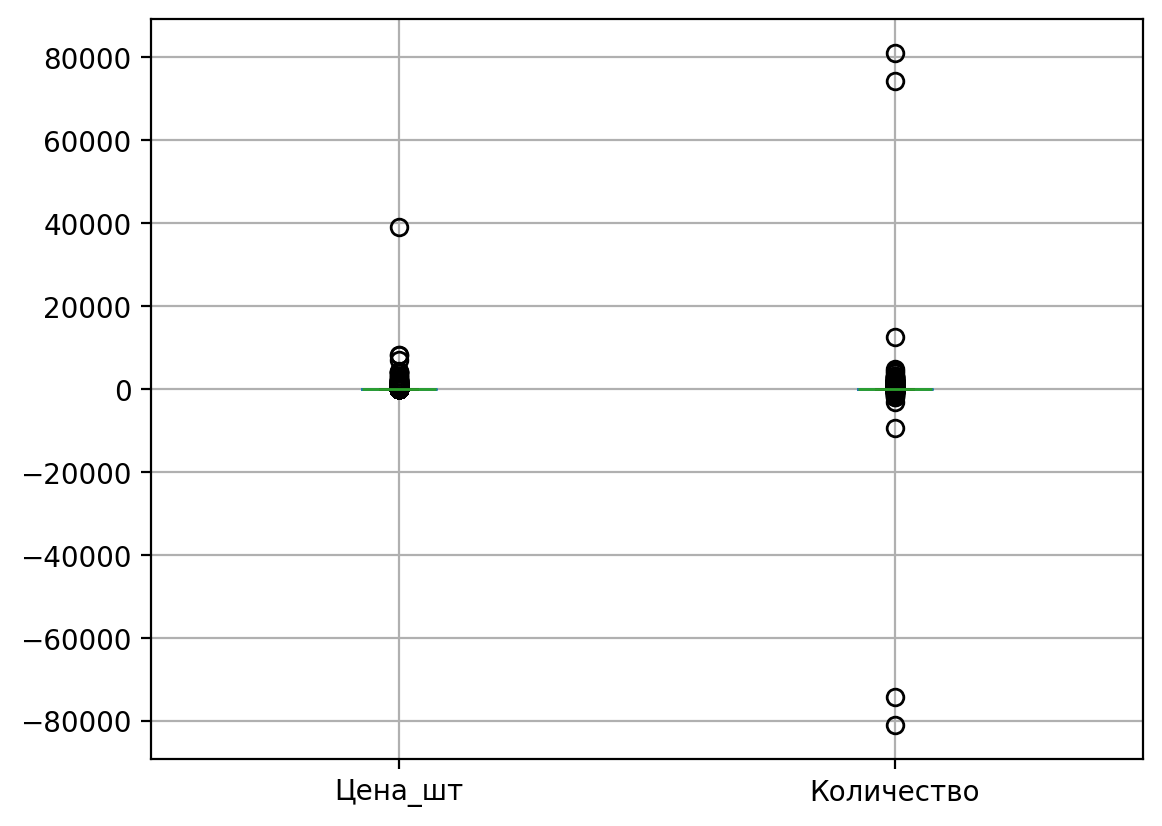

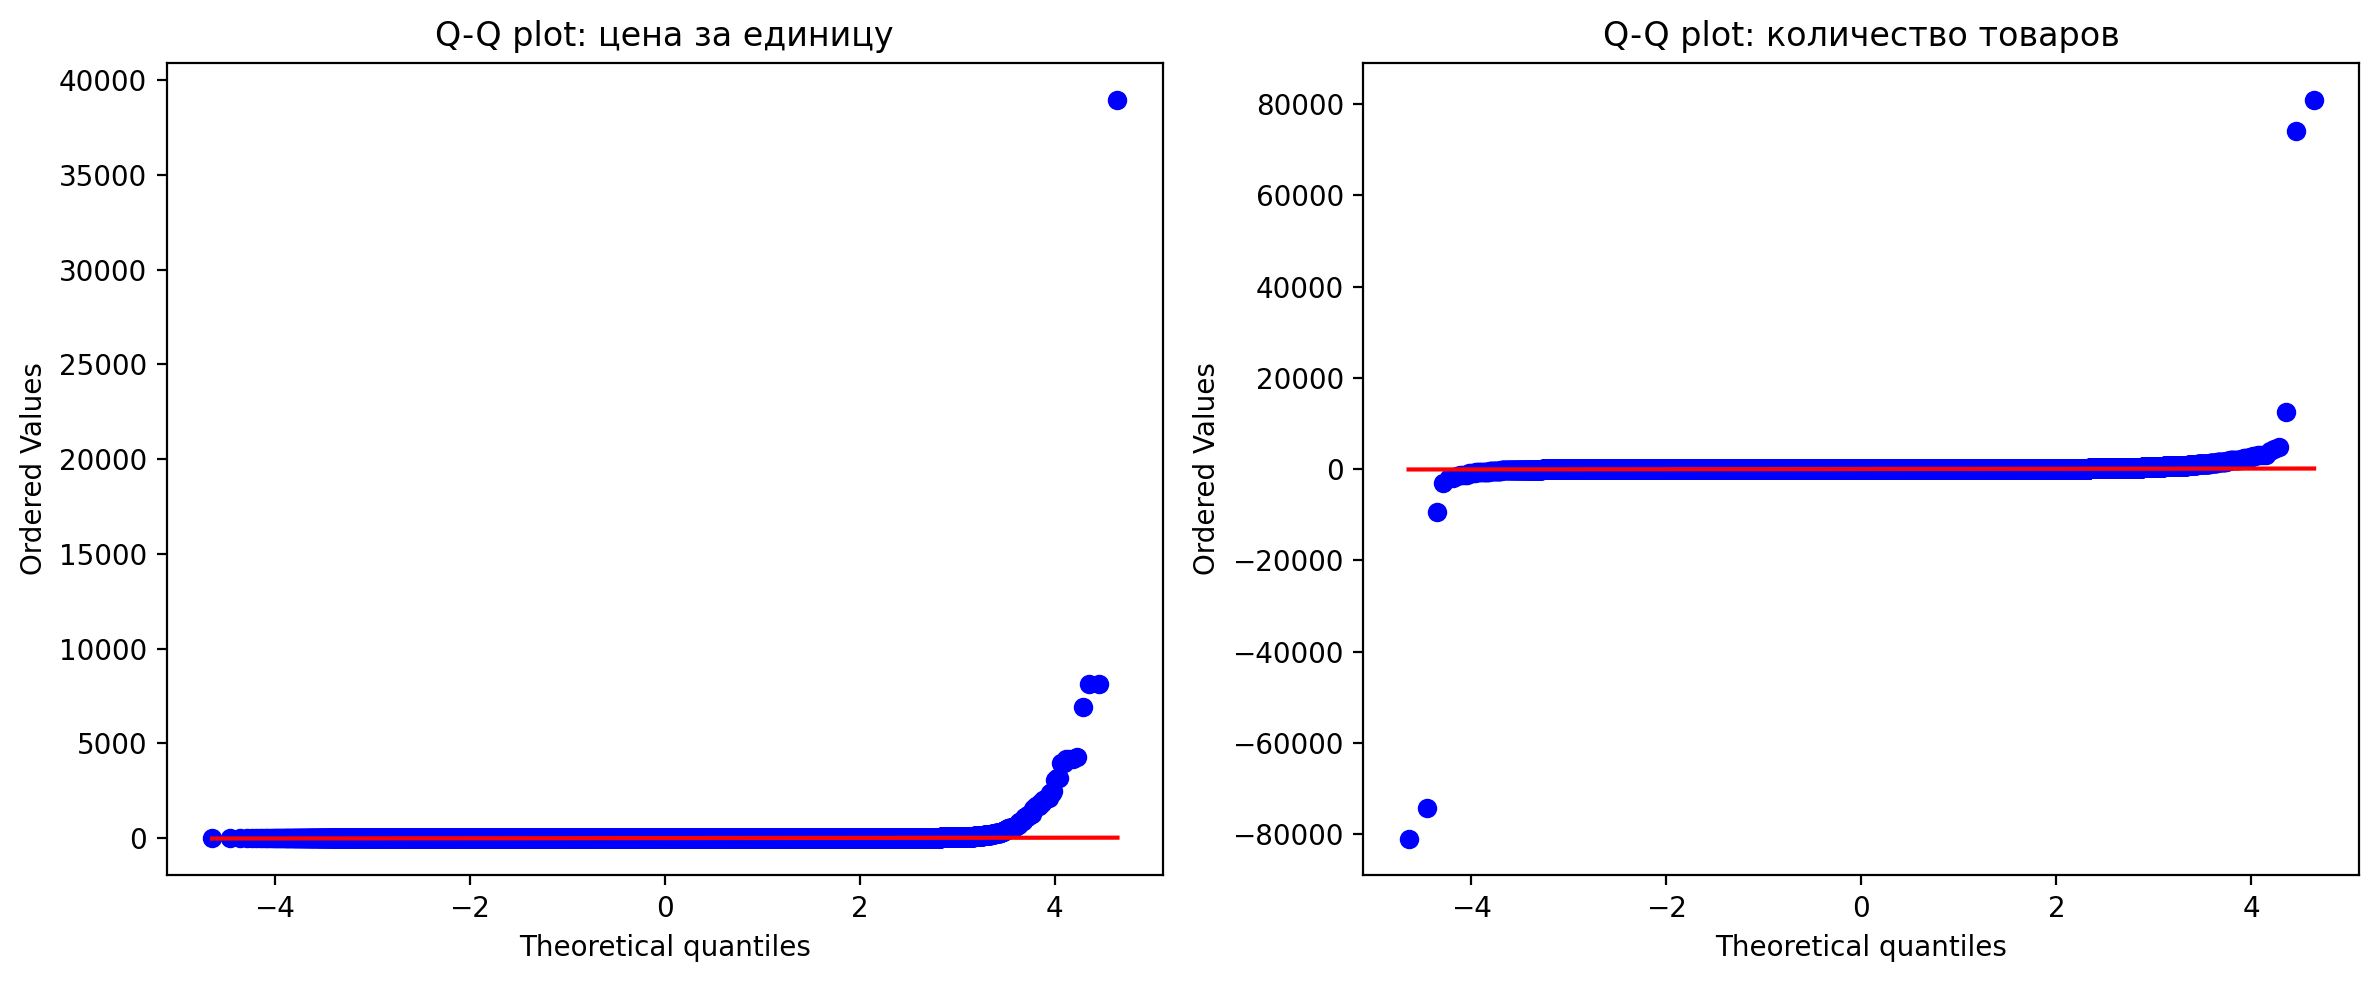

Как мы видим распределение не нормальное,лучше использовать IQR для работы с выбросами


In [13]:
#Построим график ящик с усами для няглядности выбросов в столбцах Цена_шт и Количество
df[['Цена_шт','Количество']].boxplot()
print('''
На первый взгляд, в обоих столбцах есть выбросы.
В столбце «Цена_шт» есть очень дорогие товары — вблизи 40 000.
В столбце «Количество» есть выбросы с двух сторон усов. Как мы уже выяснили, отрицательные значения — это возвраты.
''')

# Чтобы понять какой метод использовать для очистки от выбросов(Z-показатель или  IQR (межквартильный размах)),
# нужно определить какое рааспределение у данных(нормальное или же нет)

import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(df['Цена_шт'], dist="norm", plot=axes[0])
axes[0].set_title('Q-Q plot: цена за единицу')

stats.probplot(df['Количество'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot: количество товаров')

plt.tight_layout()
plt.show()
print('Как мы видим распределение не нормальное,лучше использовать IQR для работы с выбросами')
      


<class 'pandas.core.frame.DataFrame'>
Index: 399297 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Номер_заказа   399297 non-null  object        
 1   Код_Товара     399297 non-null  object        
 2   Товар          399297 non-null  object        
 3   Количество     399297 non-null  float64       
 4   Дата_покупки   399297 non-null  datetime64[ns]
 5   Цена_шт        399297 non-null  float64       
 6   ID_покупателя  399297 non-null  object        
 7   Страна         399297 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(5)
memory usage: 27.4+ MB


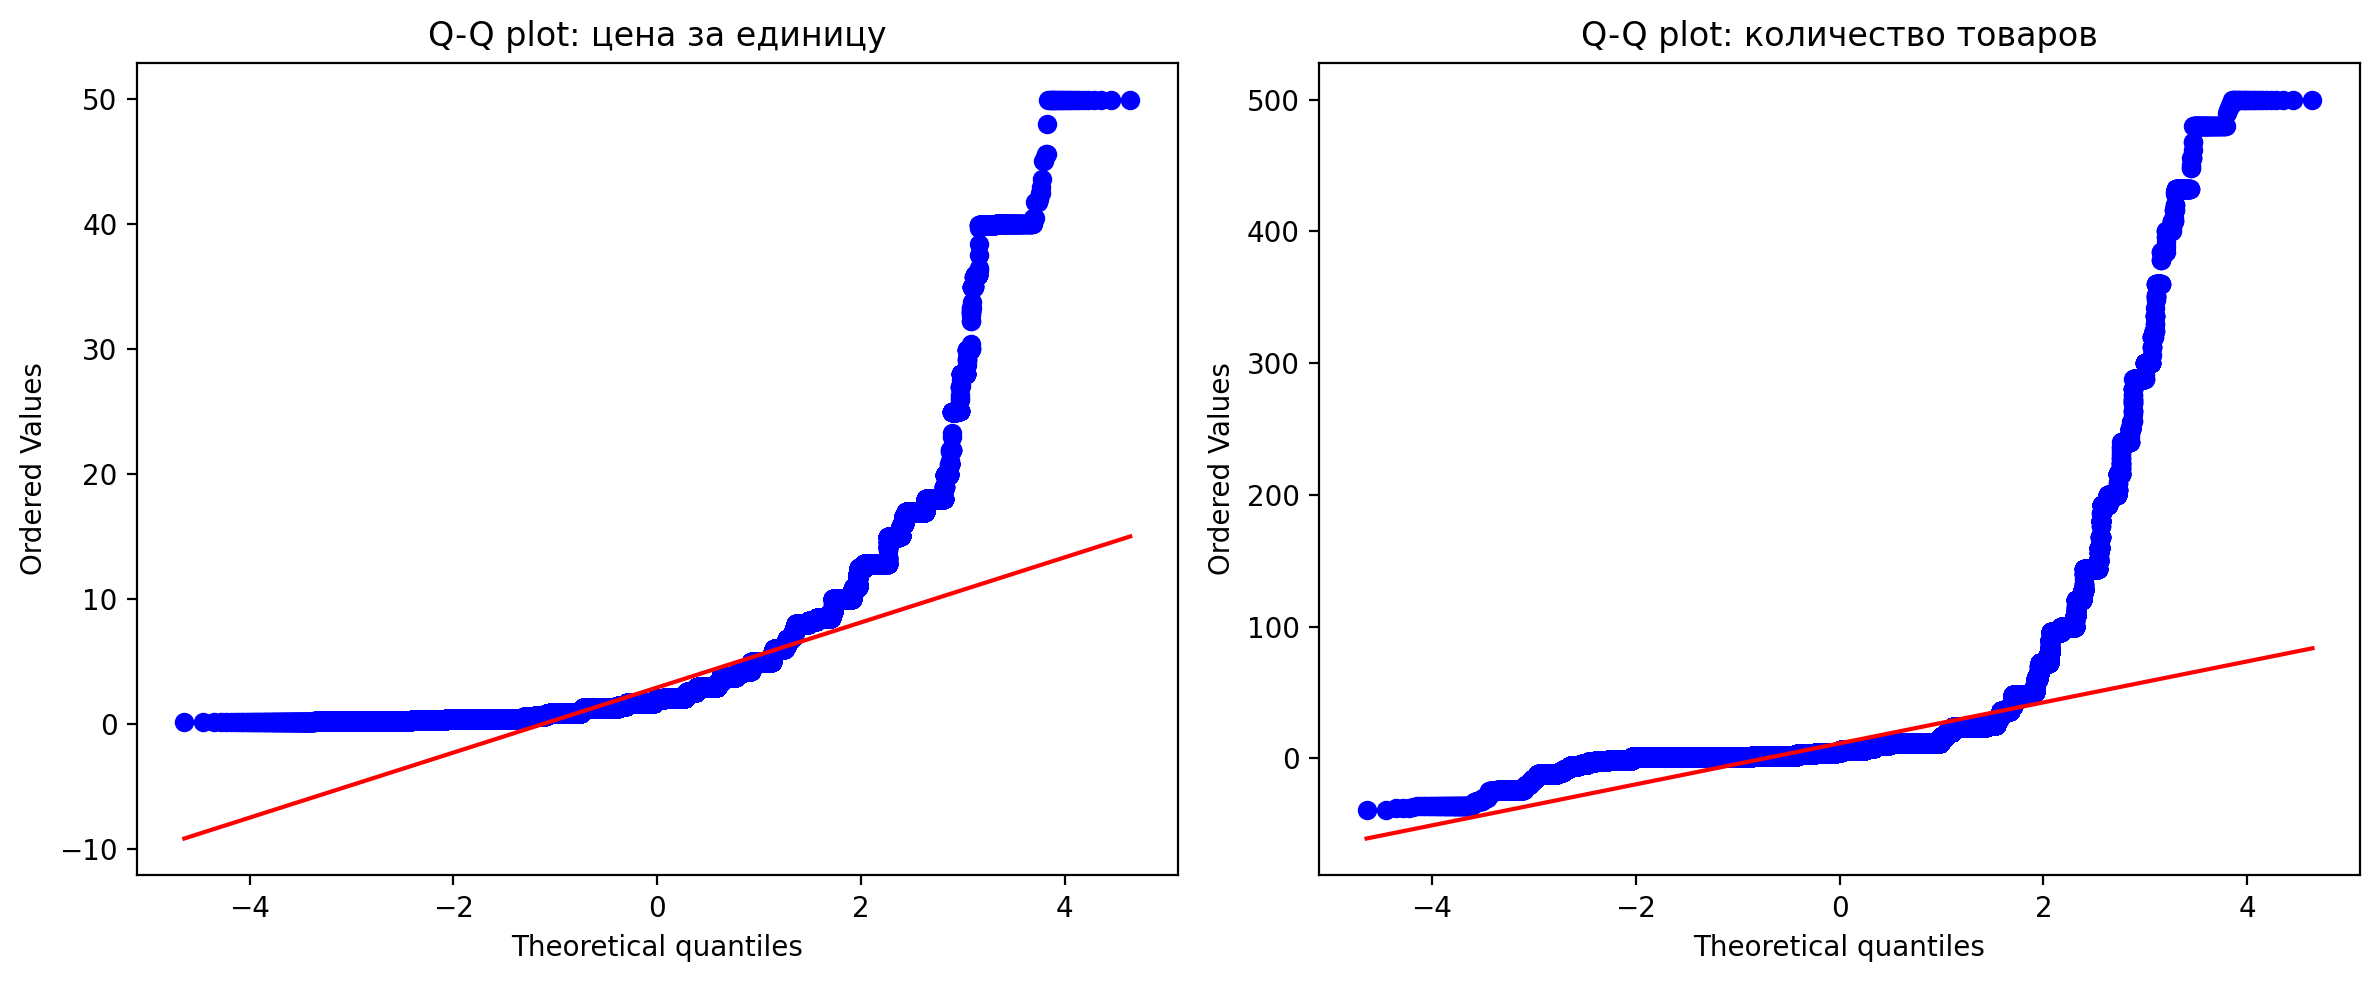


Выводы:

Распределение данных в столбцах с ценами и количеством ненормальное, привести его близко к нормальному не получается. 
Так получается, потому что выбросы имеют большое количество вхождений.
Если мы берём 75‑й и 25‑й квартили, как это обычно принято, то потеряем больше половины датасета. 
Я считаю, так делать нельзя, так как теряется много смысла.
Решение — сгруппировать цены и количество в определённые категории и уже внутри категорий найти выбросы.



In [14]:
#Я считаю что бизнес логика никак не нарушена от больших выбросов так как абсолютно логично можно объяснить данные,
#но лучше от редких данных с большими значениями избавится чтобы не портить ML
# Используем метод IQR на 0.1 и 0.99 процентиле
df_clean = df.copy()
p_01 = df_clean['Цена_шт'].quantile(0.001)
p_99 = df_clean['Цена_шт'].quantile(0.999)
q_01 = df_clean['Количество'].quantile(0.001)
q_99 = df_clean['Количество'].quantile(0.999)
df_clean_price = df_clean.loc[
    (p_99 > df_clean['Цена_шт']) & 
    (df_clean['Цена_шт'] > p_01) & 
    (q_99 > df_clean['Количество']) &
    (df_clean['Количество'] > q_01)
    ]
df_clean_price.info()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(df_clean_price['Цена_шт'], dist="norm", plot=axes[0])
axes[0].set_title('Q-Q plot: цена за единицу')

stats.probplot(df_clean_price['Количество'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q plot: количество товаров')

plt.tight_layout()
plt.show()
#df_clean_price[['Цена_шт','Количество']].boxplot()
print('''
Выводы:

Распределение данных в столбцах с ценами и количеством ненормальное, привести его близко к нормальному не получается. 
Так получается, потому что выбросы имеют большое количество вхождений.
Если мы берём 75‑й и 25‑й квартили, как это обычно принято, то потеряем больше половины датасета. 
Я считаю, так делать нельзя, так как теряется много смысла.
Решение — сгруппировать цены и количество в определённые категории и уже внутри категорий найти выбросы.
'''
 )

<class 'pandas.core.frame.DataFrame'>
Index: 401463 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Номер_заказа      401463 non-null  object        
 1   Код_Товара        401463 non-null  object        
 2   Товар             401463 non-null  object        
 3   Количество        401463 non-null  float64       
 4   Дата_покупки      401463 non-null  datetime64[ns]
 5   Цена_шт           401463 non-null  float64       
 6   ID_покупателя     401463 non-null  object        
 7   Страна            401463 non-null  object        
 8   Категория_объёма  401463 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), object(5)
memory usage: 36.0+ MB



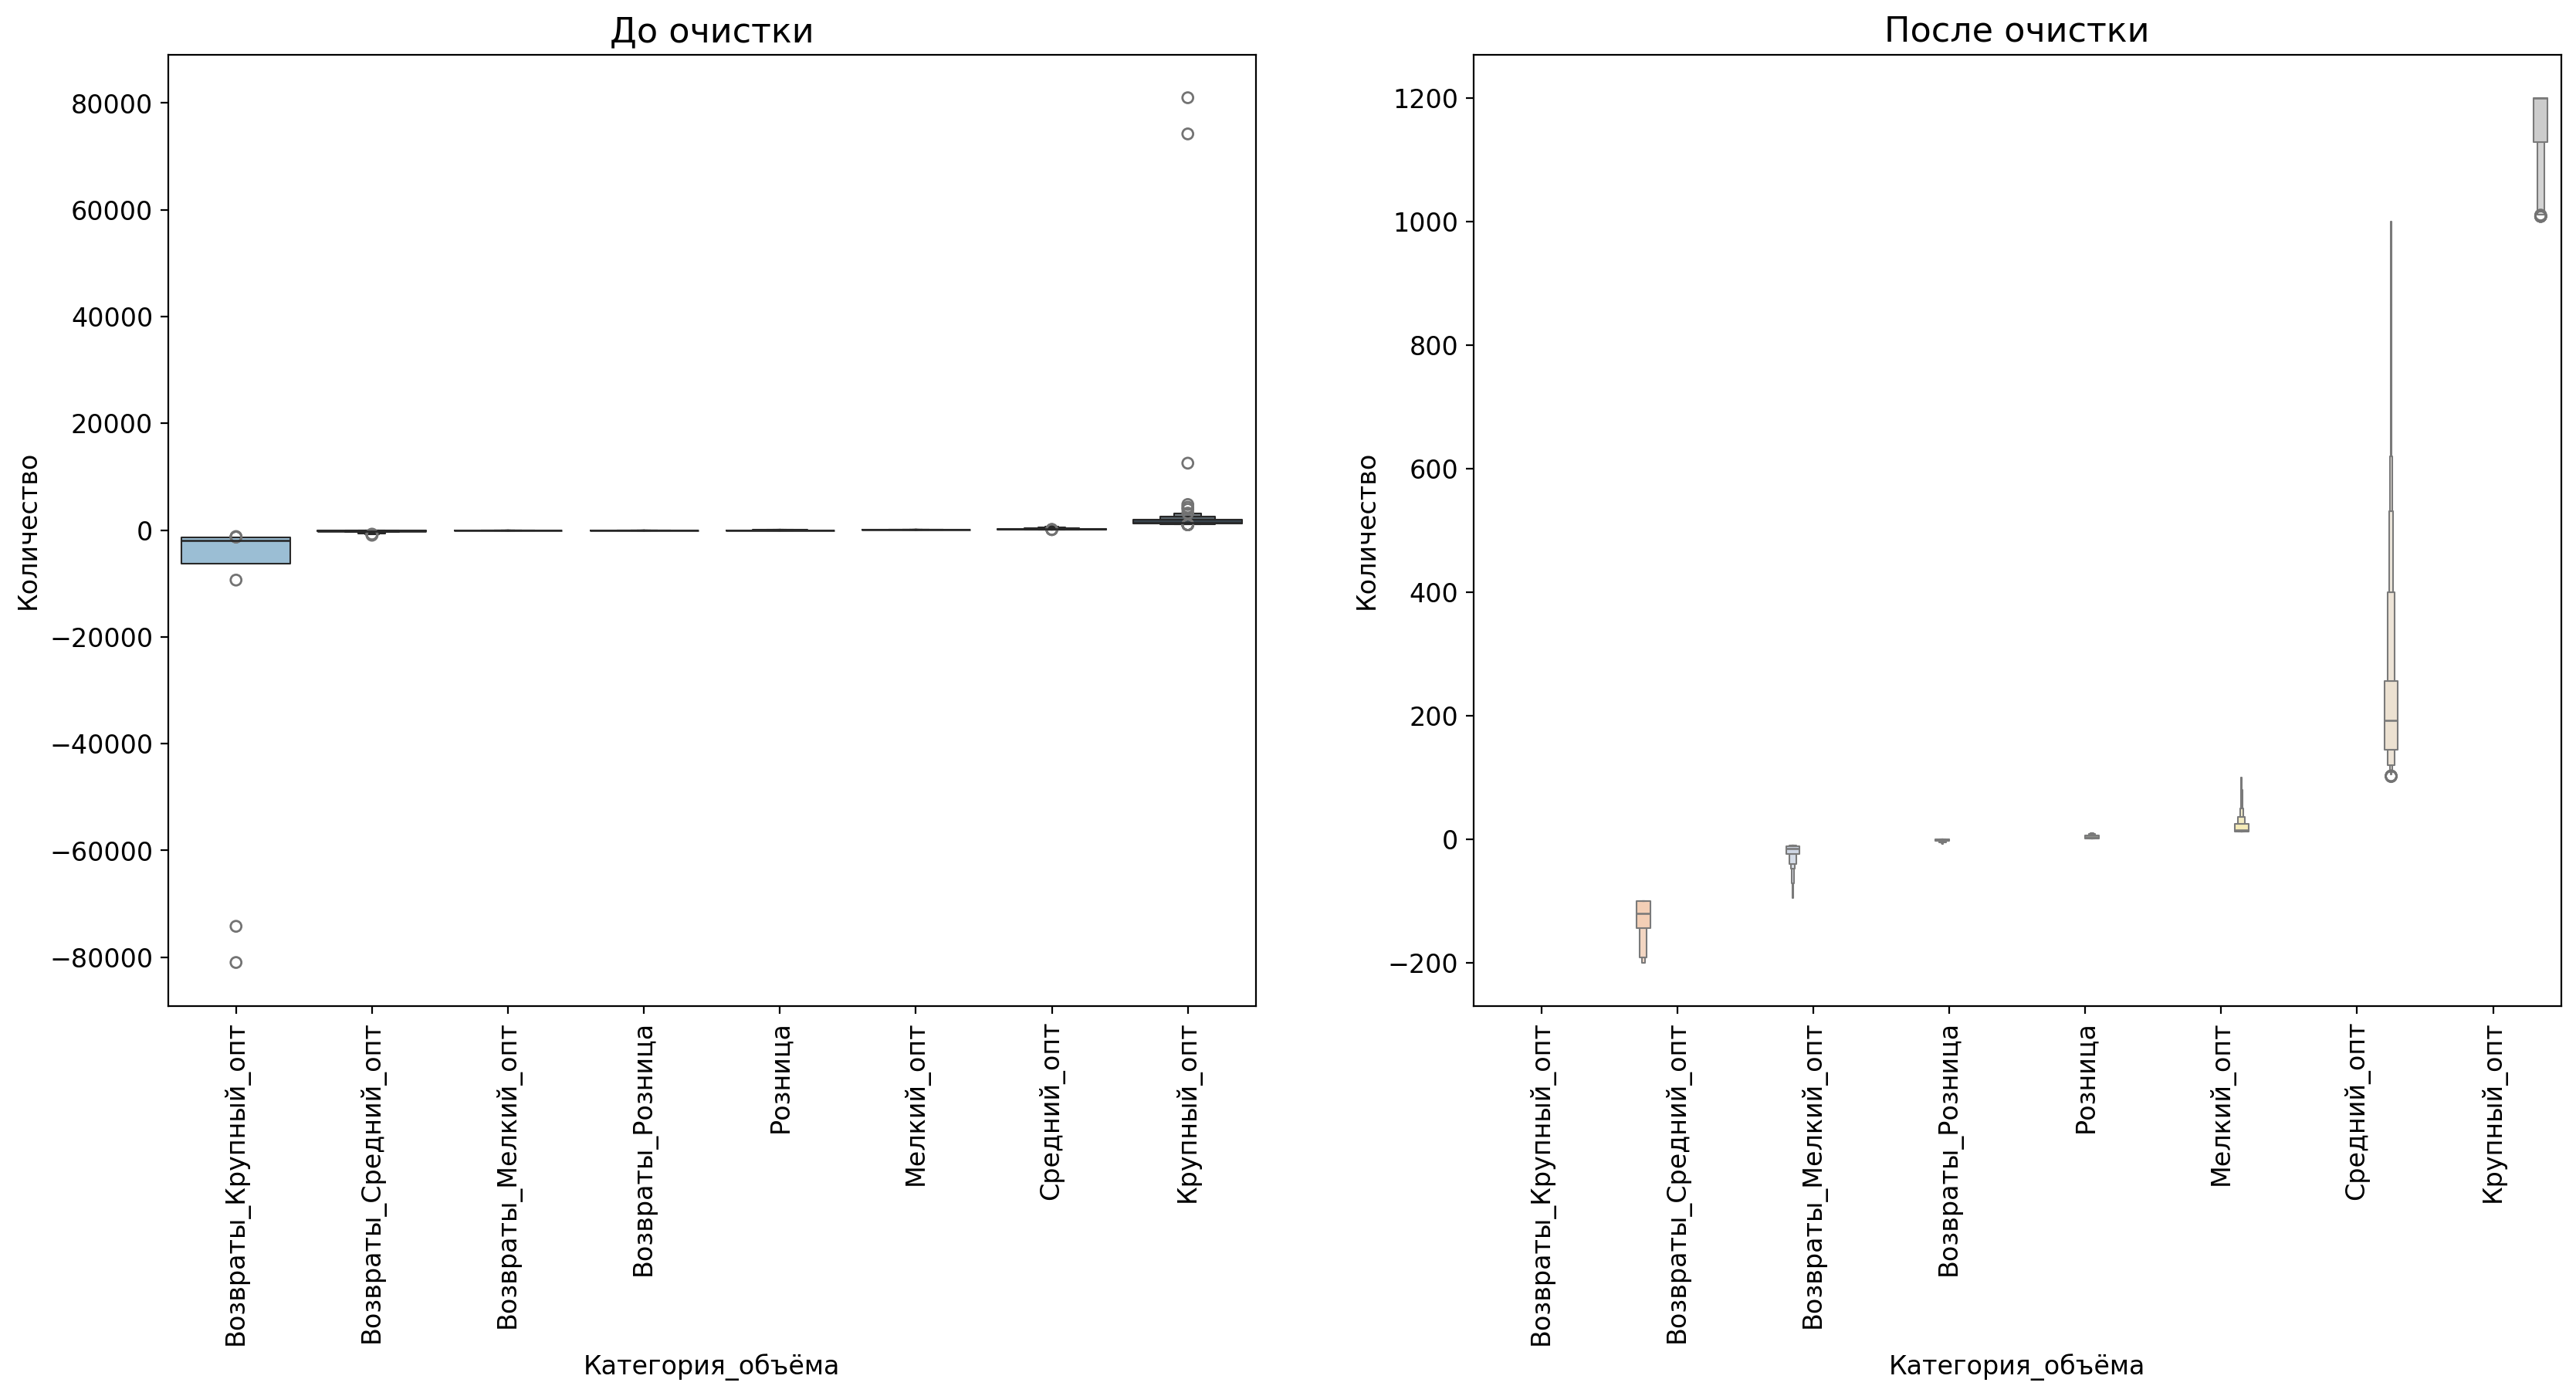

In [15]:
#У меня не получается явно выделить выбросы так как считаю что бизнес логика пострадает
# Я выделю группы и уже внутри них найду выбросы
df_quantity_group = df.copy()

#df_quantity_group.info()
bins = [-float('inf'),-1000,-100,-10, 0, 10, 100, 1000, float('inf')]
labels = ['Возвраты_Крупный_опт','Возвраты_Средний_опт','Возвраты_Мелкий_опт','Возвраты_Розница','Розница', 'Мелкий_опт','Средний_опт','Крупный_опт']

df_quantity_group['Категория_объёма'] = pd.cut(df_quantity_group['Количество'], bins=bins, labels=labels, right=True)
#display(df_quant_group)

df_quantity_group_clean = df_quantity_group.copy()
Q0002 = df_quantity_group['Количество'].quantile(0.0002)
Q9998 = df_quantity_group['Количество'].quantile(0.9998)
df_quantity_group_clean = df_quantity_group.loc[
    (df_quantity_group['Количество'] >= Q0002) & 
    (df_quantity_group['Количество'] <= Q9998)]


#print(df_quantity_group_clean)

#Построим boxenplot столбца Категория_объёма до очистки и после для визуального понимания того что поменялось.
#plt.rcParams['font.size'] = 12
fig, axes = plt.subplots(1 ,2,figsize=(20,8))
ax0=sns.boxenplot(data=df_quantity_group,x='Категория_объёма',y='Количество',ax=axes[0],palette='Blues_d',hue='Категория_объёма',legend=False )
ax0.set_title('До очистки',fontsize=16);
ax0.set_xlabel('Категория_объёма',fontsize=12)
ax0.set_ylabel('Количество',fontsize=12)
ax0.tick_params(labelsize=12)
ax0.tick_params(axis='x', labelrotation=90)
ax1=sns.boxenplot(data=df_quantity_group_clean,x='Категория_объёма',y='Количество',ax=axes[1],palette='Pastel2',hue='Категория_объёма',legend=False)
ax1.set_title('После очистки',fontsize=16);
ax1.set_xlabel('Категория_объёма',fontsize=12)
ax1.set_ylabel('Количество',fontsize=12)
ax1.tick_params(labelsize=12)
ax1.tick_params(axis='x', labelrotation=90)

df_quantity_group_clean.info()
print()

<class 'pandas.core.frame.DataFrame'>
Index: 401384 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Номер_заказа      401384 non-null  object        
 1   Код_Товара        401384 non-null  object        
 2   Товар             401384 non-null  object        
 3   Количество        401384 non-null  float64       
 4   Дата_покупки      401384 non-null  datetime64[ns]
 5   Цена_шт           401384 non-null  float64       
 6   ID_покупателя     401384 non-null  object        
 7   Страна            401384 non-null  object        
 8   Категория_объёма  401384 non-null  category      
 9   Сегмент_товара    401384 non-null  category      
dtypes: category(2), datetime64[ns](1), float64(2), object(5)
memory usage: 36.4+ MB



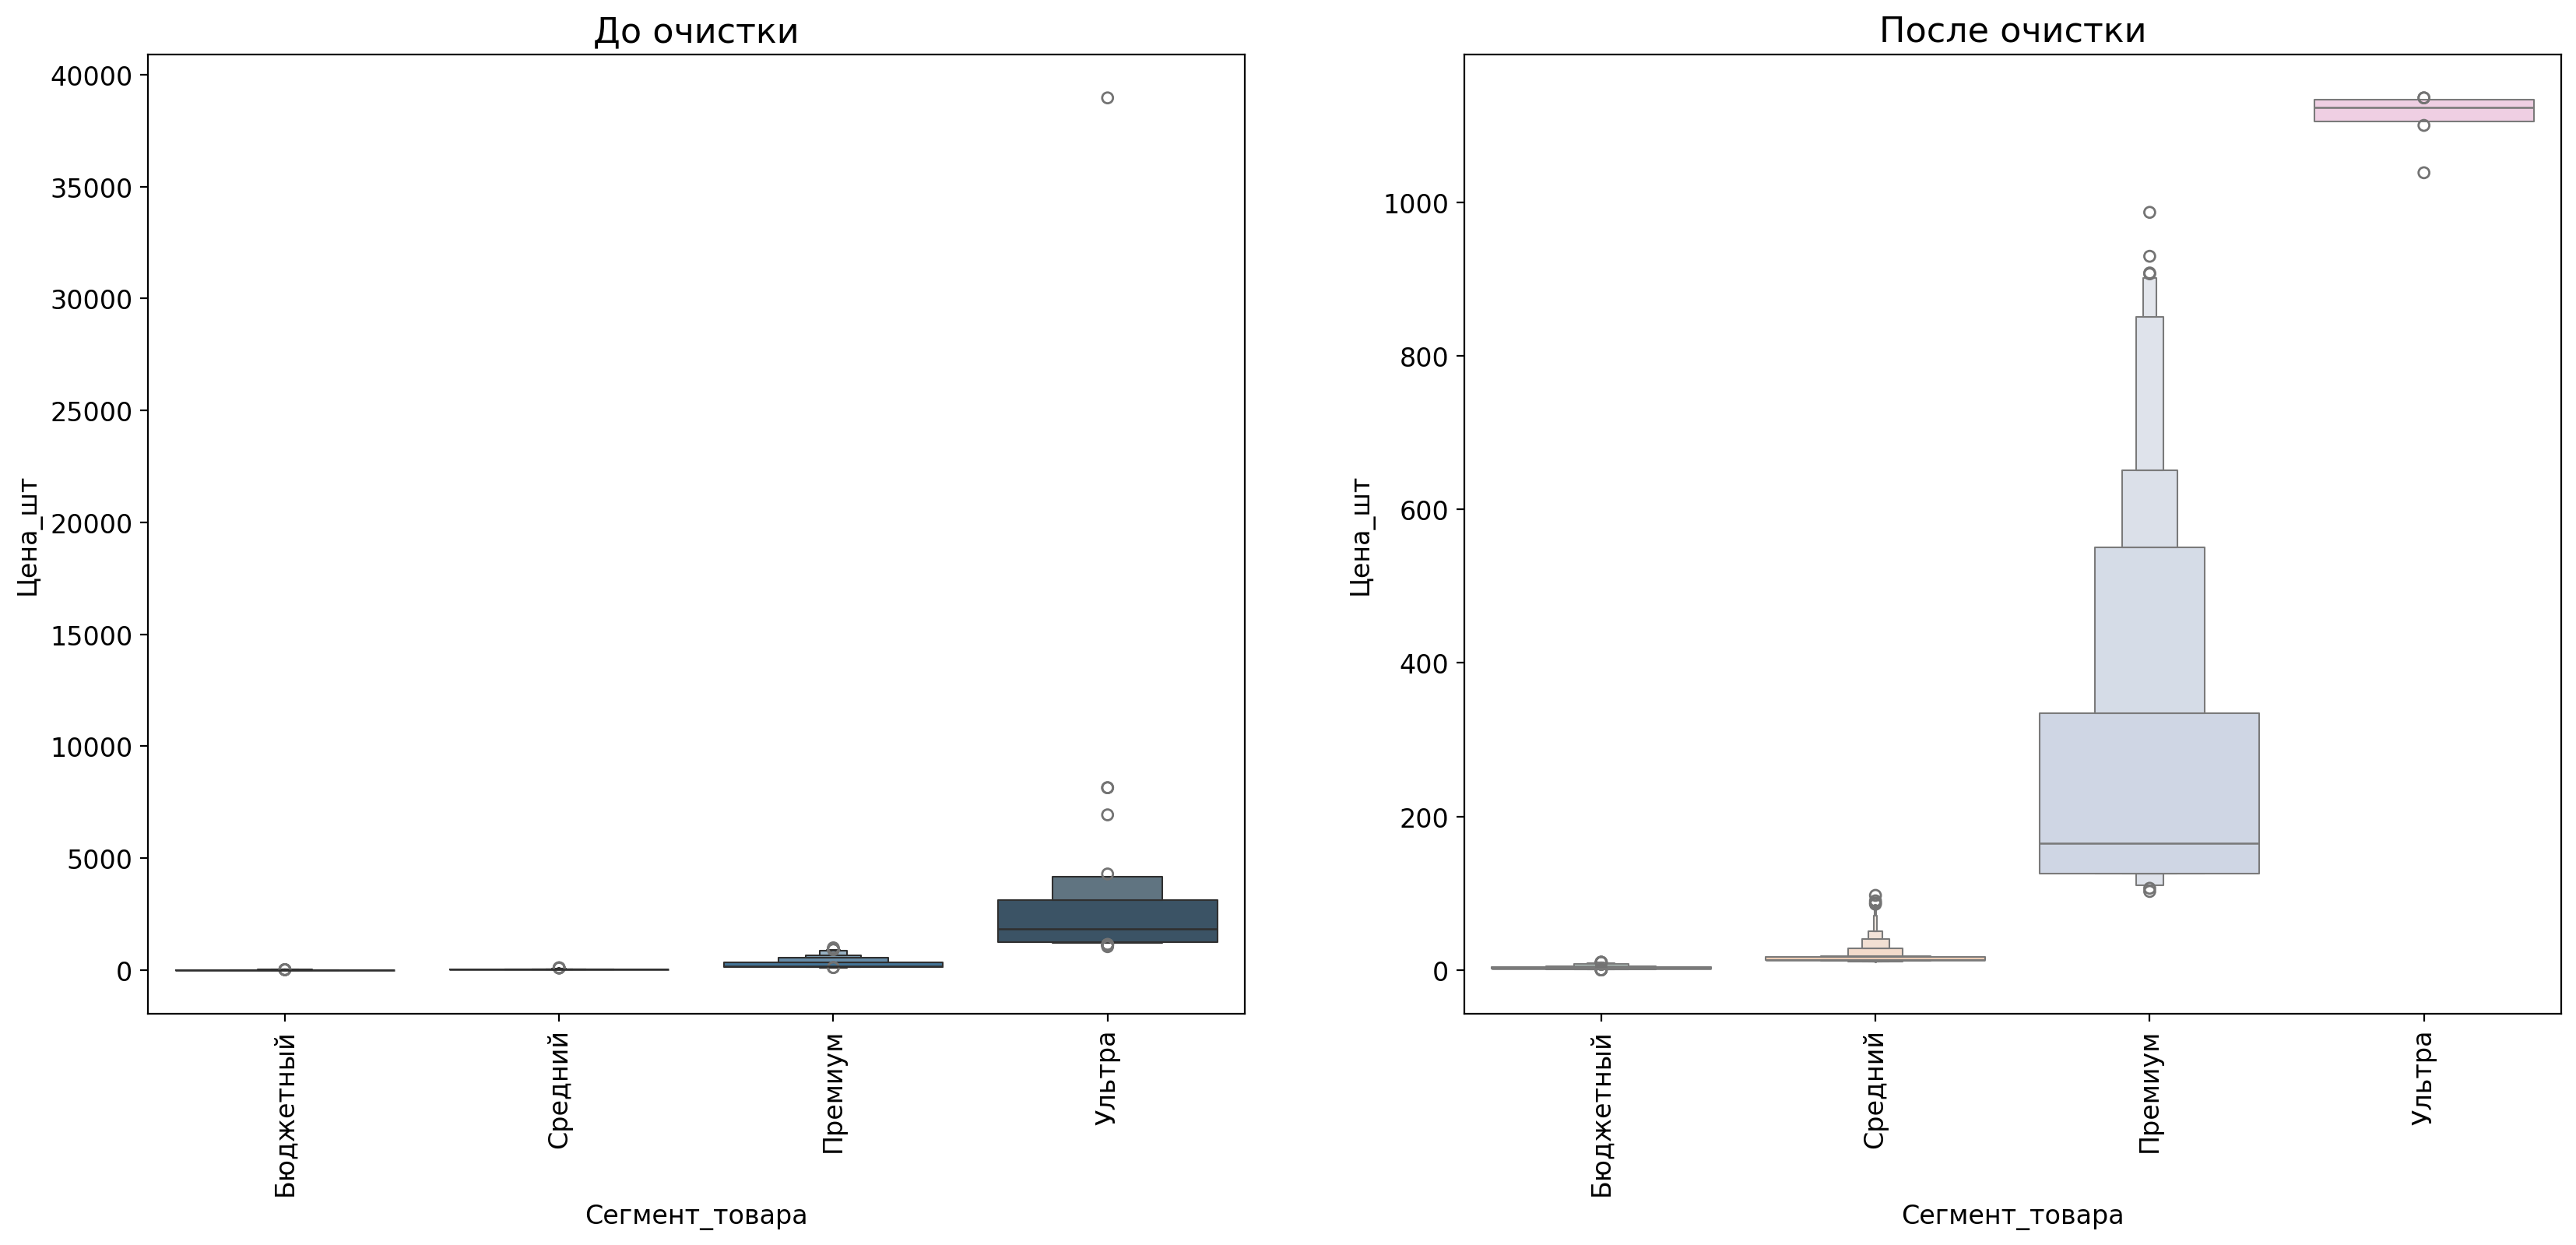

In [16]:
#Создадим группы для оценки стоимость товара (Бюджетный_сегмент,Средний_сегмент,Премиум_сегмент,Ультра_сегмент)
df_price_group = df_quantity_group_clean.copy()
#df_revenue_group.info()
bins = [ 0, 10, 100, 1000, float('inf')]
labels = ['Бюджетный', 'Средний','Премиум','Ультра']

df_price_group['Сегмент_товара'] = pd.cut(df_price_group['Цена_шт'], bins=bins, labels=labels, right=False)
#display(df_quant_group)

df_price_group_clean = df_price_group.copy()
Q0001 = df_price_group['Цена_шт'].quantile(0.0001)
Q9999 = df_price_group['Цена_шт'].quantile(0.9999)
df_price_group_clean = df_price_group.loc[
    (df_quantity_group['Цена_шт'] >= Q0001) & 
    (df_quantity_group['Цена_шт'] <= Q9999)]


#print(df_price_group_clean)

#Построим boxenplot столбца price до очистки и после для визуального понимания того что поменялось.
#plt.rcParams['font.size'] = 12
fig, axes = plt.subplots(1 ,2,figsize=(20,8))
ax0=sns.boxenplot(data=df_price_group,x='Сегмент_товара',y='Цена_шт',ax=axes[0],palette='Blues_d',hue='Сегмент_товара',legend=False )
ax0.set_title('До очистки',fontsize=16);
ax0.set_xlabel('Сегмент_товара',fontsize=12)
ax0.set_ylabel('Цена_шт',fontsize=12)
ax0.tick_params(labelsize=12)
ax0.tick_params(axis='x', labelrotation=90)
ax1=sns.boxenplot(data=df_price_group_clean,x='Сегмент_товара',y='Цена_шт',ax=axes[1],palette='Pastel2',hue='Сегмент_товара',legend=False)
ax1.set_title('После очистки',fontsize=16);
ax1.set_xlabel('Сегмент_товара',fontsize=12)
ax1.set_ylabel('Цена_шт',fontsize=12)
ax1.tick_params(labelsize=12)
ax1.tick_params(axis='x', labelrotation=90)

df_price_group_clean.info()
print()

#### Результаты:
После первого блока очистки в датасете осталось 401 604 строки. Если бы я использовал классический метод работы с выбросами (IQR, Q25, Q75), он не подошёл бы, так как распределение было асимметричным, ненормальным, — я бы потерял больше половины датасета.

Мной было принято решение о создании групп внутри столбцов «Цена_шт» и «Количество». Таким образом, я получил новые сегменты клиента с относительно нормальным распределением и понятной бизнес‑логикой.

По итогу в датасете остаётся 401 384 строки, что говорит нам о том, что бизнес‑логике мешали всего 220 строк. Я не исключаю, что такая очистка имеет субъективный характер, но в плане логики, я считаю, надо оставлять как можно больше строк с новыми группами, чтобы понимать, что вообще происходит с продажами.

Далее под каждый метод анализа будет проводиться дополнительная очистка, исходя из специфики метода.



#### 3. Агрегация данных на уровне клиента (Customer‑level features)


#### Recency (давность последнего заказа).
Агрегация по параметрам
1) ID_покупателя (Групировка по столбцу)
2) Итоговая_выручка(Количество_шт * цена_за_шт)
3) Средний_чек (Итоговая_выручка/количество_заказов )
4) Количество_заказов(сумма строк по номеру_заказа)
5) Количество_купленных_товаров(сумма всех товаров > 0)
6) Количество_вернувших_товаров (сумма всех товаров < 0)
7) Доля_выкупа_% ((Количество_купленных_товаров - Количество_вернувших_товаров) / Количество_купленных_товаров )
8) Средняя_цена_товара 
9) Среднее_количество_выкупленных_товаров( Количество_купленных_товаров.mean() )
10) Сегмент_товаров (Бюджетный, Средний,Премиум,Ультра)
11) Сегмент_объемов (Возвраты_Крупный_опт,Возвраты_Средний_опт,Возвраты_Мелкий_опт,Возвраты_Розница,Розница, Мелкий_опт,Средний_опт,Крупный_опт)
12) Последний_заказ_дней(сколько дней назад был последний заказ)


In [17]:
df_client = df_price_group_clean.copy()
#Найдем все заказы которые вернули 

#clean_quant = df_client.loc[df_client['Количество']>0]
#df_client['Выручка'] = clean_quant['Цена_шт']*clean_quant['Количество']
df_client['Выручка'] = df_client['Цена_шт']*df_client['Количество']
# Ищем дату последней покупки
reference_date = df_client['Дата_покупки'].max() + pd.Timedelta(days=1)

#print(clean_quant)
#df_client['Выручка'].info()

df_client_group = df_client.groupby(['ID_покупателя'], as_index=False).agg (
    Количество_заказов = ('Номер_заказа', 'count'),
    Итоговая_выручка = ('Выручка', 'sum'),
    Средняя_цена_товара = ('Цена_шт', 'mean'),
    Среднее_количество_выкупленных_товаров = ('Количество','mean'),
    Количество_купленных_товаров = ('Количество',lambda x: x[x > 0].sum()),
    #Разница между последней датой покупки у всех и конкретного клиента
    Последний_заказ_дней = ('Дата_покупки', lambda x: (reference_date - x.max()).days),
    Количество_вернувших_товаров = ('Количество',  lambda x: abs(x[x < 0].sum()))
)

df_client_group['Средний_чек'] = df_client_group['Итоговая_выручка']/df_client_group['Количество_заказов']
df_client_group['Доля_выкупа_%'] = (df_client_group['Количество_купленных_товаров']-df_client_group['Количество_вернувших_товаров'])/df_client_group['Количество_купленных_товаров']*100


#display(df_client_group)
#Дополним таблицу сегментами товаров и сегментами объемов покупок

bins = [0, 10, 100, 1000,float('inf')]
labels_price = ['Бюджетный','Средний','Премиум','Ультра']
labels_quant = ['Розничный','Мелкий_опт','Средний_опт','Крупный_опт']


df_client_group['Сегмент_товаров'] = pd.cut(df_client_group['Средняя_цена_товара'],bins=bins, labels=labels_price, right=False)
df_client_group['Сегмент_объемов'] = pd.cut(df_client_group['Среднее_количество_выкупленных_товаров'],bins=bins, labels=labels_quant, right=False)

#display(df_client_group)
#df_client_group.info()

rows_with_any_nan = df_client_group[df_client_group.isna().any(axis=1)]
#print(len(rows_with_any_nan))          # сколько таких строк
#print(rows_with_any_nan.head())       # посмотреть примеры

#У нас появились строки где среднее количество товаров <=0.Такие строки нам не нужны.
df_client_group = df_client_group.loc[
    (df_client_group['Доля_выкупа_%'] >= 0) &
    (df_client_group['Доля_выкупа_%'] <= 100) &
    (df_client_group['Итоговая_выручка'] >= 0)
]
#df_client_group.info()

cols = [
    'ID_покупателя',
    'Итоговая_выручка',
    'Средний_чек',
    'Количество_заказов',
    'Количество_купленных_товаров',
    'Количество_вернувших_товаров',
    'Доля_выкупа_%',
    'Средняя_цена_товара',
    'Среднее_количество_выкупленных_товаров',
    'Сегмент_товаров',	
    'Сегмент_объемов',
    'Последний_заказ_дней',
    
]


df_client_group = df_client_group[cols]
display(df_client_group)
#df_client_group.info()


,ID_покупателя,Итоговая_выручка,Средний_чек,Количество_заказов,Количество_купленных_товаров,Количество_вернувших_товаров,Доля_выкупа_%,Средняя_цена_товара,Среднее_количество_выкупленных_товаров,Сегмент_товаров,Сегмент_объемов,Последний_заказ_дней
0,12347.0,4310.00,23.681319,182,2458.0,0.0,100.000000,2.644011,13.505495,Бюджетный,Мелкий_опт,2
1,12348.0,1797.24,57.975484,31,2341.0,0.0,100.000000,5.764839,75.516129,Бюджетный,Мелкий_опт,75
2,12349.0,1757.55,24.076027,73,631.0,0.0,100.000000,8.289041,8.643836,Бюджетный,Розничный,19
3,12350.0,334.40,19.670588,17,197.0,0.0,100.000000,3.841176,11.588235,Бюджетный,Мелкий_опт,310
4,12352.0,1545.41,16.267474,95,536.0,66.0,87.686567,23.274737,4.947368,Средний,Розничный,36
...,...,...,...,...,...,...,...,...,...,...,...,...
4357,18280.0,180.60,18.060000,10,45.0,0.0,100.000000,4.765000,4.500000,Бюджетный,Розничный,278
4358,18281.0,80.82,11.545714,7,54.0,0.0,100.000000,5.622857,7.714286,Бюджетный,Розничный,181
4359,18282.0,176.60,13.584615,13,103.0,5.0,95.145631,4.821538,7.538462,Бюджетный,Розничный,8
4360,18283.0,2045.53,2.837074,721,1357.0,0.0,100.000000,1.628752,1.882108,Бюджетный,Розничный,4


#### Результаты:
1) С помощью агрегации по ID_покупателя мы получили новый датафрейм на 4319 строк и 12 столбцов
2) Теперь у меня есть бизнес метрики по которым я дальше буду искать корреляции, сегементировать и делать прогнозы.

#### 4. Поиск скрытых корреляций


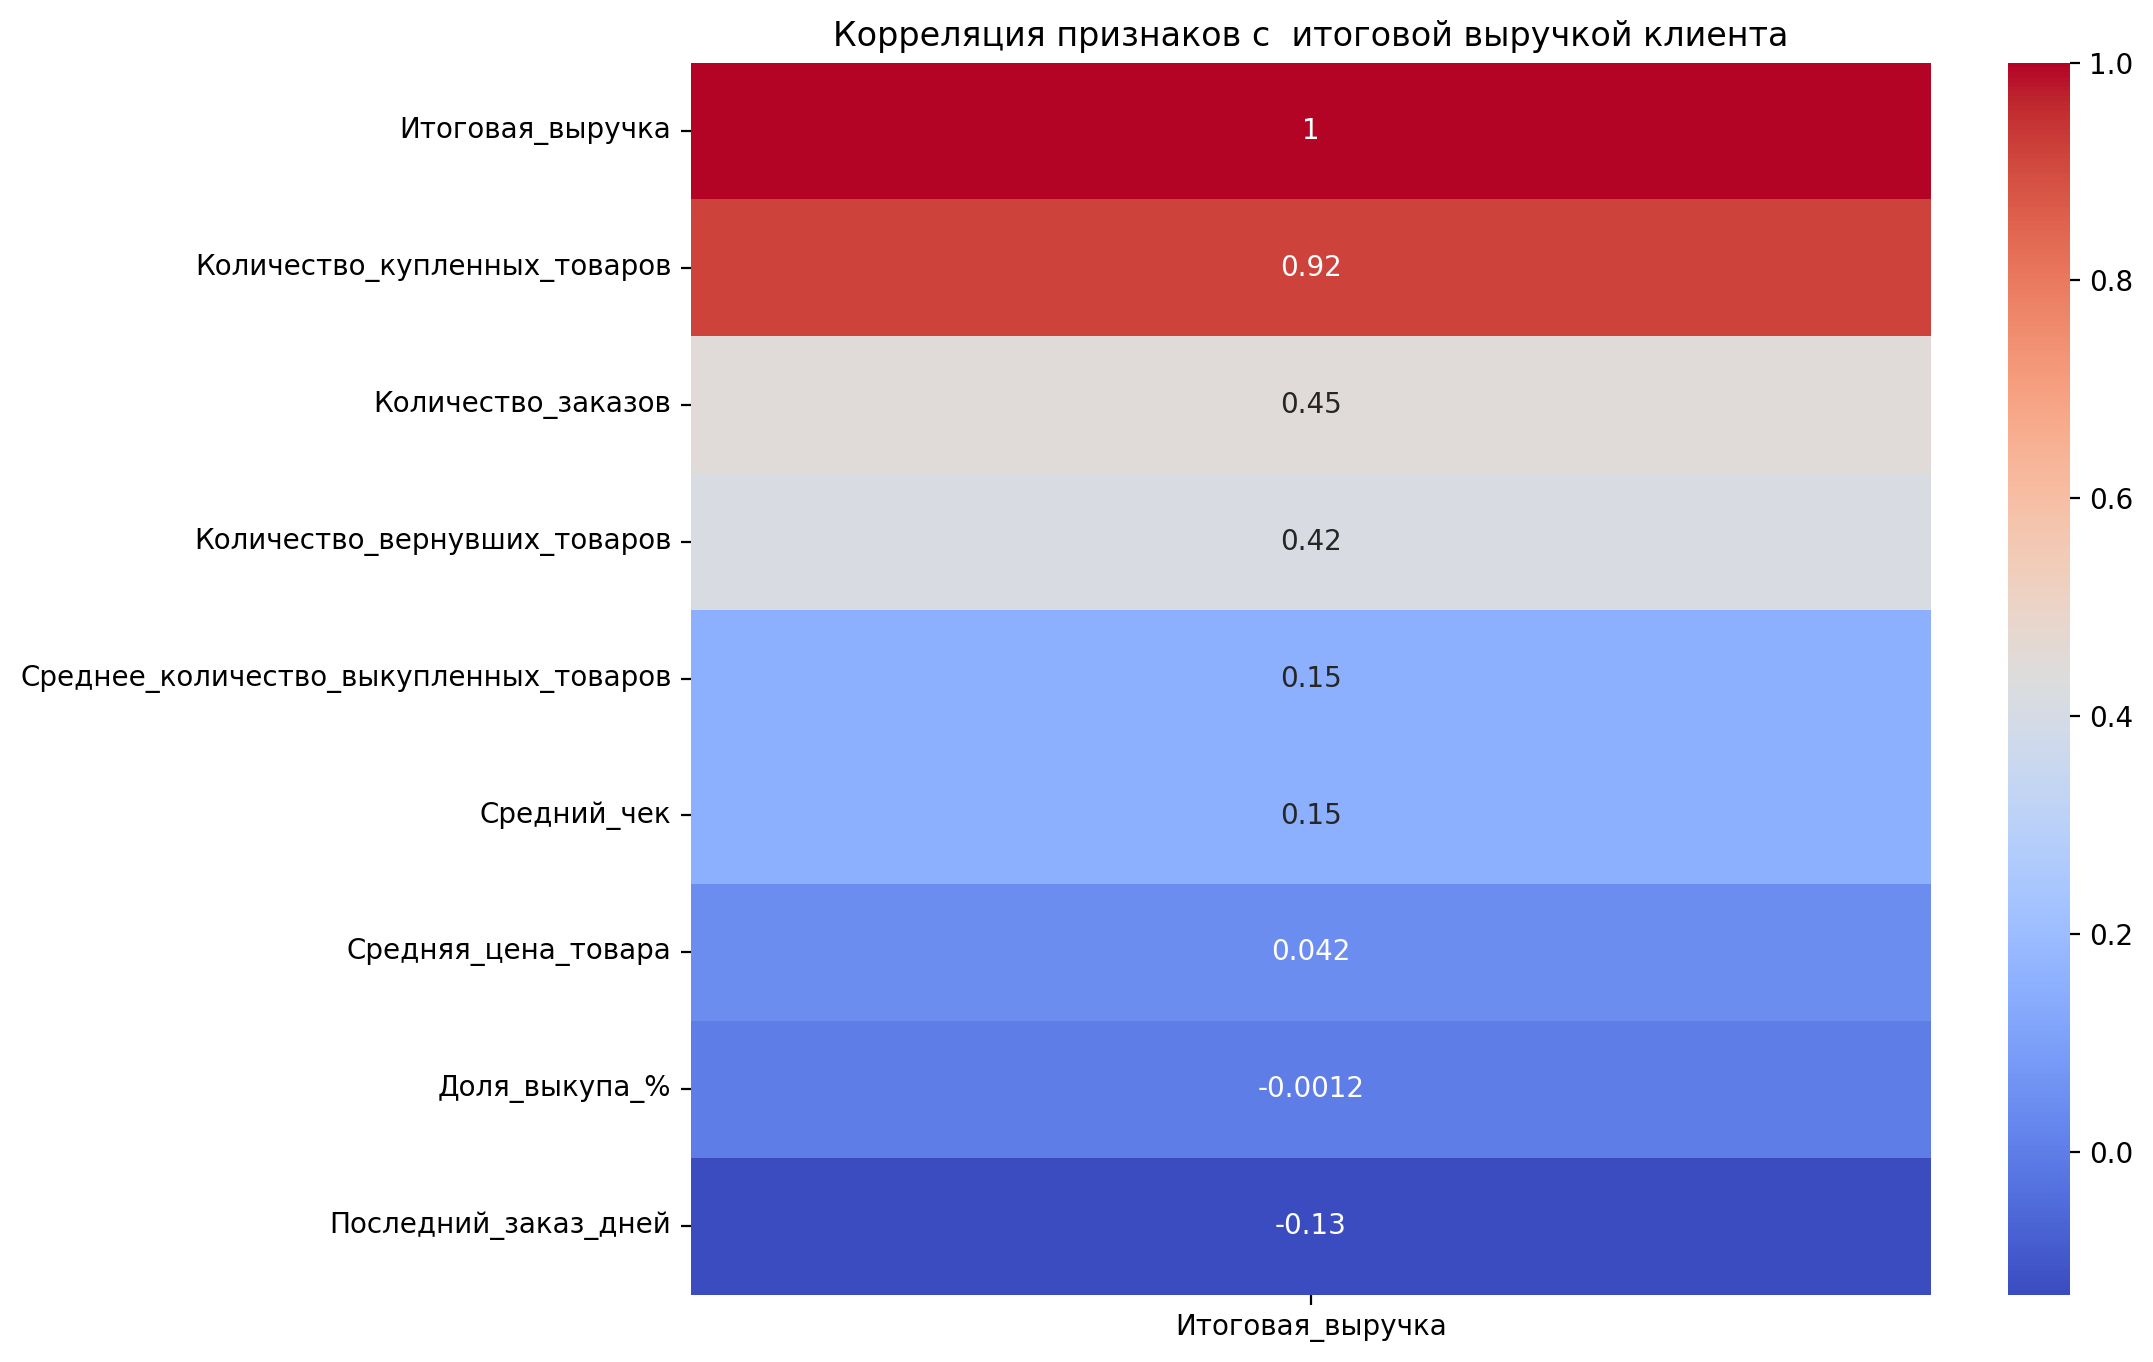

In [18]:
corr = df_client_group.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr[['Итоговая_выручка']].sort_values('Итоговая_выручка', ascending=False), annot=True, cmap='coolwarm')
plt.title('Корреляция признаков с  итоговой выручкой клиента')
plt.show()

#### Результаты:
1) Самый весомый признак получения выручки — «Количество_купленных_товаров». Это говорит о том, что данные, которые я анализирую, являются реальными: логично, что чем больше куплено товаров, тем выше выручка.
2) Косвенные признаки получения выручки не имеют весомых долей. Это означает, что на данном этапе мы не нашли скрытых признаков, влияющих на выручку.

#### 5. Сегментация клиентов и формирование «портрета потребителя»

In [19]:
df_segment = df_client_group.copy()
#RFM сегментация

q = df_segment[['Последний_заказ_дней','Количество_заказов','Итоговая_выручка']].quantile([0.25,0.5,0.75])
def r_score(x,col):
    if x <= q[col][0.25]: return 4
    elif x <= q[col][0.5]:return 3
    elif x <= q[col][0.75]: return 2
    else: return 1
def fm_score (x,col):
    if x >= q[col][0.75]: return 4
    elif x >= q[col][0.50]: return 3
    elif x >= q[col][0.25]: return 2
    else: return 1

df_segment['R'] = df_segment['Последний_заказ_дней'].apply(r_score,col = 'Последний_заказ_дней')
df_segment['F'] = df_segment['Количество_заказов'].apply(fm_score, col='Количество_заказов')
df_segment['M'] = df_segment['Итоговая_выручка'].apply(fm_score, col='Итоговая_выручка')

df_segment['RFM_score'] = df_segment['R'] + df_segment['F'] + df_segment['M']

def RFM_segment (score):
    if score >= 10: return 'Лучшие'
    elif score >= 7: return 'Перспективные'
    elif score >= 4: return 'Спящие'
    else: return 'Потерянные'

df_segment['Сегмент_RFM'] = df_segment['RFM_score'].apply(RFM_segment)
#display(df_segment)

# --- ABC: по выручке (правило Парето) ---
# Сортируем прямо в df_segment — это нормально для сегментации
df_segment = df_segment.sort_values('Итоговая_выручка', ascending=False).copy()
total_rev = df_segment['Итоговая_выручка'].sum()
df_segment['Доля_накопленная'] = df_segment['Итоговая_выручка'].cumsum() / total_rev

def abc_segment(cum_share):
    if cum_share <= 0.80: return 'A'
    elif cum_share <= 0.95: return 'B'
    else: return 'C'

df_segment['Сегмент_ABC'] = df_segment['Доля_накопленная'].apply(abc_segment)
#display(df_segment)


# --- Качество клиента: возвраты и объём ---
def quality_segment(row):
    r_pct = row['Доля_выкупа_%']
    if 70 > r_pct > 50:
        return 'Проблемный'
    # Надёжные: мало возвратов, стабильная активность
    if  r_pct >= 99:
        return 'Надёжный'
    # Высокий риск
    if r_pct <= 50:
        return 'Бан'
    return 'Стандартный'

df_segment['Сегмент_качество'] = df_segment.apply(quality_segment, axis=1)
#display(df_segment)


# 1. Распределение по RFM: сколько клиентов в каждом сегменте
print("Распределение по RFM:")
print(df_segment['Сегмент_RFM'].value_counts().sort_index())

# 2. ABC: сколько клиентов и какая доля выручки в каждом сегменте (проверка Парето)
abc_summary = df_segment.groupby('Сегмент_ABC').agg(
    n_clients=('ID_покупателя', 'count'),
    share_revenue=('Итоговая_выручка', lambda x: x.sum() / total_rev)
).round(3)
print("\nABC-сегментация (проверка Парето):")
print(abc_summary)

# 3. Распределение по качеству клиента
print("\nРаспределение по качеству:")
print(df_segment['Сегмент_качество'].value_counts())
#df_segment.info()

# 4 . Доля самых ценных клиентов
df_top = df_segment [ 
    (df_segment['Сегмент_RFM'] == 'Лучшие') & 
    (df_segment['Сегмент_ABC'] == 'A')& 
    (df_segment['Сегмент_качество'] == 'Надёжный')
    ]
share_top = len(df_top) / len(df_segment)
print(f"Доля самых ценных клиентов: {share_top:.2%}") 

Распределение по RFM:
Сегмент_RFM
Лучшие           1272
Перспективные    1325
Потерянные        374
Спящие           1348
Name: count, dtype: int64

ABC-сегментация (проверка Парето):
             n_clients  share_revenue
Сегмент_ABC                          
A                 1169           0.80
B                 1455           0.15
C                 1695           0.05

Распределение по качеству:
Сегмент_качество
Надёжный       3537
Стандартный     738
Проблемный       24
Бан              20
Name: count, dtype: int64
Доля самых ценных клиентов: 16.25%


#### Результаты:
1) RFM‑сегментация. Я получил новые сегменты покупателей: лучшие, перспективные, спящие, потерянные — на основе давности, частоты и выручки.
2) ABC‑сегментация по правилу Парето разделила покупателей на 3 сегмента. Каждый из этих сегментов, в зависимости от задачи, имеет разную степень важности.
3) Сегмент «Качество» был выделен отдельно для объективной оценки не просто купленных товаров, а именно выкупленных. На сегодняшний день именно такая оценка соответствует стандартам e‑commerce.
4) На данном этапе мы получили 4 сегмента покупателя и один сегмент купленного товара. Портрет потребителя теперь отвечает на такие вопросы: что покупает, сколько покупает, сколько принёс выручки, какова его ценность, как часто возвращает товары.


#### 6. Построение ML‑модели для прогноза вероятности покупки и прогноза среднего чека.


##### Подготовка датафрейма для логистической регрессии. Нужно создать новый параметр - купит_через_неделю.


In [20]:

df_1 = df.copy()

df_1 = (
    df_1.groupby('ID_покупателя', as_index=False)
    .agg(
        Дата_покупки_мин=('Дата_покупки', 'min'),
        Дата_покупки_макс=('Дата_покупки', 'max'),
        Количество_заказов=('Дата_покупки', 'count')
    )
)

# 2. Считаем разницу в днях
df_1['Сколько_дней_клиент'] = ((df_1['Дата_покупки_макс'] - df_1['Дата_покупки_мин']).dt.days)+1

# 3. Считаем средний интервал между заказами (в днях)
# Если заказов 1, то ставим NaN (нет интервалов)
df_1['Средний_интервал_дней'] = np.where(
    df_1['Количество_заказов'] > 1,
    df_1['Сколько_дней_клиент'] / (df_1['Количество_заказов']-1),
    np.nan
)

# 4. Сегментируем: «покупает примерно раз в 7 дней 
bins = [0.0, 7.0, float('inf')]
labels = [1, 0]  # 1 = раз в месяц и чаще, 0 = реже
df_1['Купит_через_неделю'] = pd.cut(
    df_1['Средний_интервал_дней'],
    bins=bins,
    labels=labels,
    right=False
)

#display(df_1)

df_merged= pd.merge(
    df_segment,
    df_1[['ID_покупателя','Сколько_дней_клиент','Средний_интервал_дней', 'Купит_через_неделю']],  # берём только нужные столбцы из df_1
    on='ID_покупателя',
    how='left'  # left — чтобы все строки из df_segment остались, даже если нет совпадения
)
a =  df_merged[df_merged.isna().any(axis=1)]
df_merged.dropna(inplace = True)


display(df_merged)


,ID_покупателя,Итоговая_выручка,Средний_чек,Количество_заказов,Количество_купленных_товаров,Количество_вернувших_товаров,Доля_выкупа_%,Средняя_цена_товара,Среднее_количество_выкупленных_товаров,Сегмент_товаров,...,F,M,RFM_score,Сегмент_RFM,Доля_накопленная,Сегмент_ABC,Сегмент_качество,Сколько_дней_клиент,Средний_интервал_дней,Купит_через_неделю
0,14646.0,270176.06,130.142611,2076,189907.0,292.0,99.846241,2.598738,91.336705,Бюджетный,...,4,4,12,Лучшие,0.032672,A,Надёжный,354,0.169866,1
1,18102.0,259499.09,600.692338,432,64124.0,1.0,99.998441,4.859097,148.432870,Бюджетный,...,4,4,12,Лучшие,0.064052,A,Надёжный,367,0.849537,1
2,17450.0,168609.21,493.009386,342,58727.0,208.0,99.645819,9.625409,171.108187,Бюджетный,...,4,4,12,Лучшие,0.084441,A,Надёжный,360,1.031519,1
3,14911.0,133363.53,22.646210,5889,80238.0,2565.0,96.803260,4.121768,13.189506,Бюджетный,...,4,4,12,Лучшие,0.100569,A,Стандартный,373,0.063253,1
4,12415.0,123725.45,159.440013,776,77374.0,428.0,99.446843,3.221418,99.157216,Бюджетный,...,4,4,11,Лучшие,0.115530,A,Надёжный,314,0.404118,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4314,18268.0,0.00,0.000000,2,2.0,2.0,0.000000,12.750000,0.000000,Средний,...,1,1,4,Спящие,1.000000,C,Бан,1,1.000000,1
4315,16878.0,0.00,0.000000,6,12.0,12.0,0.000000,1.583333,0.000000,Бюджетный,...,1,1,5,Спящие,1.000000,C,Бан,60,12.000000,0
4316,13364.0,0.00,0.000000,20,71.0,71.0,0.000000,2.598000,0.000000,Бюджетный,...,2,1,5,Спящие,1.000000,C,Бан,5,0.263158,1
4317,14557.0,0.00,0.000000,32,510.0,510.0,0.000000,1.590000,0.000000,Бюджетный,...,2,1,5,Спящие,1.000000,C,Бан,22,0.709677,1


#### Логистическая регресия


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Копируем, чтобы не трогать исходные данные
df_ml1 = df_merged.copy()

# 1. Выбираем только числовые признаки (убрала пустые строки — они вызывали ошибку)
feature_cols = [
    'R',
    'F',
    'M',
    'Средний_чек',
    'Доля_выкупа_%',
    'Сколько_дней_клиент',
    'Средняя_цена_товара',
    'Количество_купленных_товаров'
]

X = df_ml1[feature_cols].copy()
y = df_ml1['Купит_через_неделю']

# 2. Разбиваем на обучение и тест (70/30), стратифицируем по целевой переменной
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 3. Модель (логистическая регрессия)
model_log_reg = LogisticRegression(max_iter=1000)
model_log_reg.fit(X_train, y_train)

# 4. Прогнозы и метрики
y_pred = model_log_reg.predict(X_test)
y_prob = model_log_reg.predict_proba(X_test)[:, 1]  # вероятность класса 1

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# 5. Важность признаков (коэффициенты)
coef_df = pd.DataFrame({
    'Признак': feature_cols,
    'Коэффициент': model_log_reg.coef_[0]
}).sort_values(by='Коэффициент', key=abs, ascending=False)

print(coef_df)

df_ml1['Вероятность_покупки_неделя_%'] = model_log_reg.predict_proba(df_ml1[feature_cols])[:, 1] * 100
display(df_ml1)

              precision    recall  f1-score   support

           0       0.93      0.71      0.80       129
           1       0.97      0.99      0.98      1150

    accuracy                           0.96      1279
   macro avg       0.95      0.85      0.89      1279
weighted avg       0.96      0.96      0.96      1279

ROC-AUC: 0.9876103808560837
                        Признак  Коэффициент
1                             F     6.221287
0                             R     0.343088
2                             M     0.293681
5           Сколько_дней_клиент    -0.047740
6           Средняя_цена_товара    -0.016545
4                 Доля_выкупа_%    -0.011470
3                   Средний_чек     0.000200
7  Количество_купленных_товаров     0.000136


,ID_покупателя,Итоговая_выручка,Средний_чек,Количество_заказов,Количество_купленных_товаров,Количество_вернувших_товаров,Доля_выкупа_%,Средняя_цена_товара,Среднее_количество_выкупленных_товаров,Сегмент_товаров,...,M,RFM_score,Сегмент_RFM,Доля_накопленная,Сегмент_ABC,Сегмент_качество,Сколько_дней_клиент,Средний_интервал_дней,Купит_через_неделю,Вероятность_покупки_неделя_%
0,14646.0,270176.06,130.142611,2076,189907.0,292.0,99.846241,2.598738,91.336705,Бюджетный,...,4,12,Лучшие,0.032672,A,Надёжный,354,0.169866,1,100.000000
1,18102.0,259499.09,600.692338,432,64124.0,1.0,99.998441,4.859097,148.432870,Бюджетный,...,4,12,Лучшие,0.064052,A,Надёжный,367,0.849537,1,99.999972
2,17450.0,168609.21,493.009386,342,58727.0,208.0,99.645819,9.625409,171.108187,Бюджетный,...,4,12,Лучшие,0.084441,A,Надёжный,360,1.031519,1,99.999954
3,14911.0,133363.53,22.646210,5889,80238.0,2565.0,96.803260,4.121768,13.189506,Бюджетный,...,4,12,Лучшие,0.100569,A,Стандартный,373,0.063253,1,99.999996
4,12415.0,123725.45,159.440013,776,77374.0,428.0,99.446843,3.221418,99.157216,Бюджетный,...,4,11,Лучшие,0.115530,A,Надёжный,314,0.404118,1,99.999999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4314,18268.0,0.00,0.000000,2,2.0,2.0,0.000000,12.750000,0.000000,Средний,...,1,4,Спящие,1.000000,C,Бан,1,1.000000,1,98.894725
4315,16878.0,0.00,0.000000,6,12.0,12.0,0.000000,1.583333,0.000000,Бюджетный,...,1,5,Спящие,1.000000,C,Бан,60,12.000000,0,90.082951
4316,13364.0,0.00,0.000000,20,71.0,71.0,0.000000,2.598000,0.000000,Бюджетный,...,1,5,Спящие,1.000000,C,Бан,5,0.263158,1,99.997749
4317,14557.0,0.00,0.000000,32,510.0,510.0,0.000000,1.590000,0.000000,Бюджетный,...,1,5,Спящие,1.000000,C,Бан,22,0.709677,1,99.995306


#### Таблица распределения вероятностей + Пончиковая диаграмма.

,Группа_вероятности,Количество_клиентов,Процент_группы
2,90% - 100%,3641,85.409336
1,50% - 90%,265,6.216280
0,0% - 50 %,357,8.374384


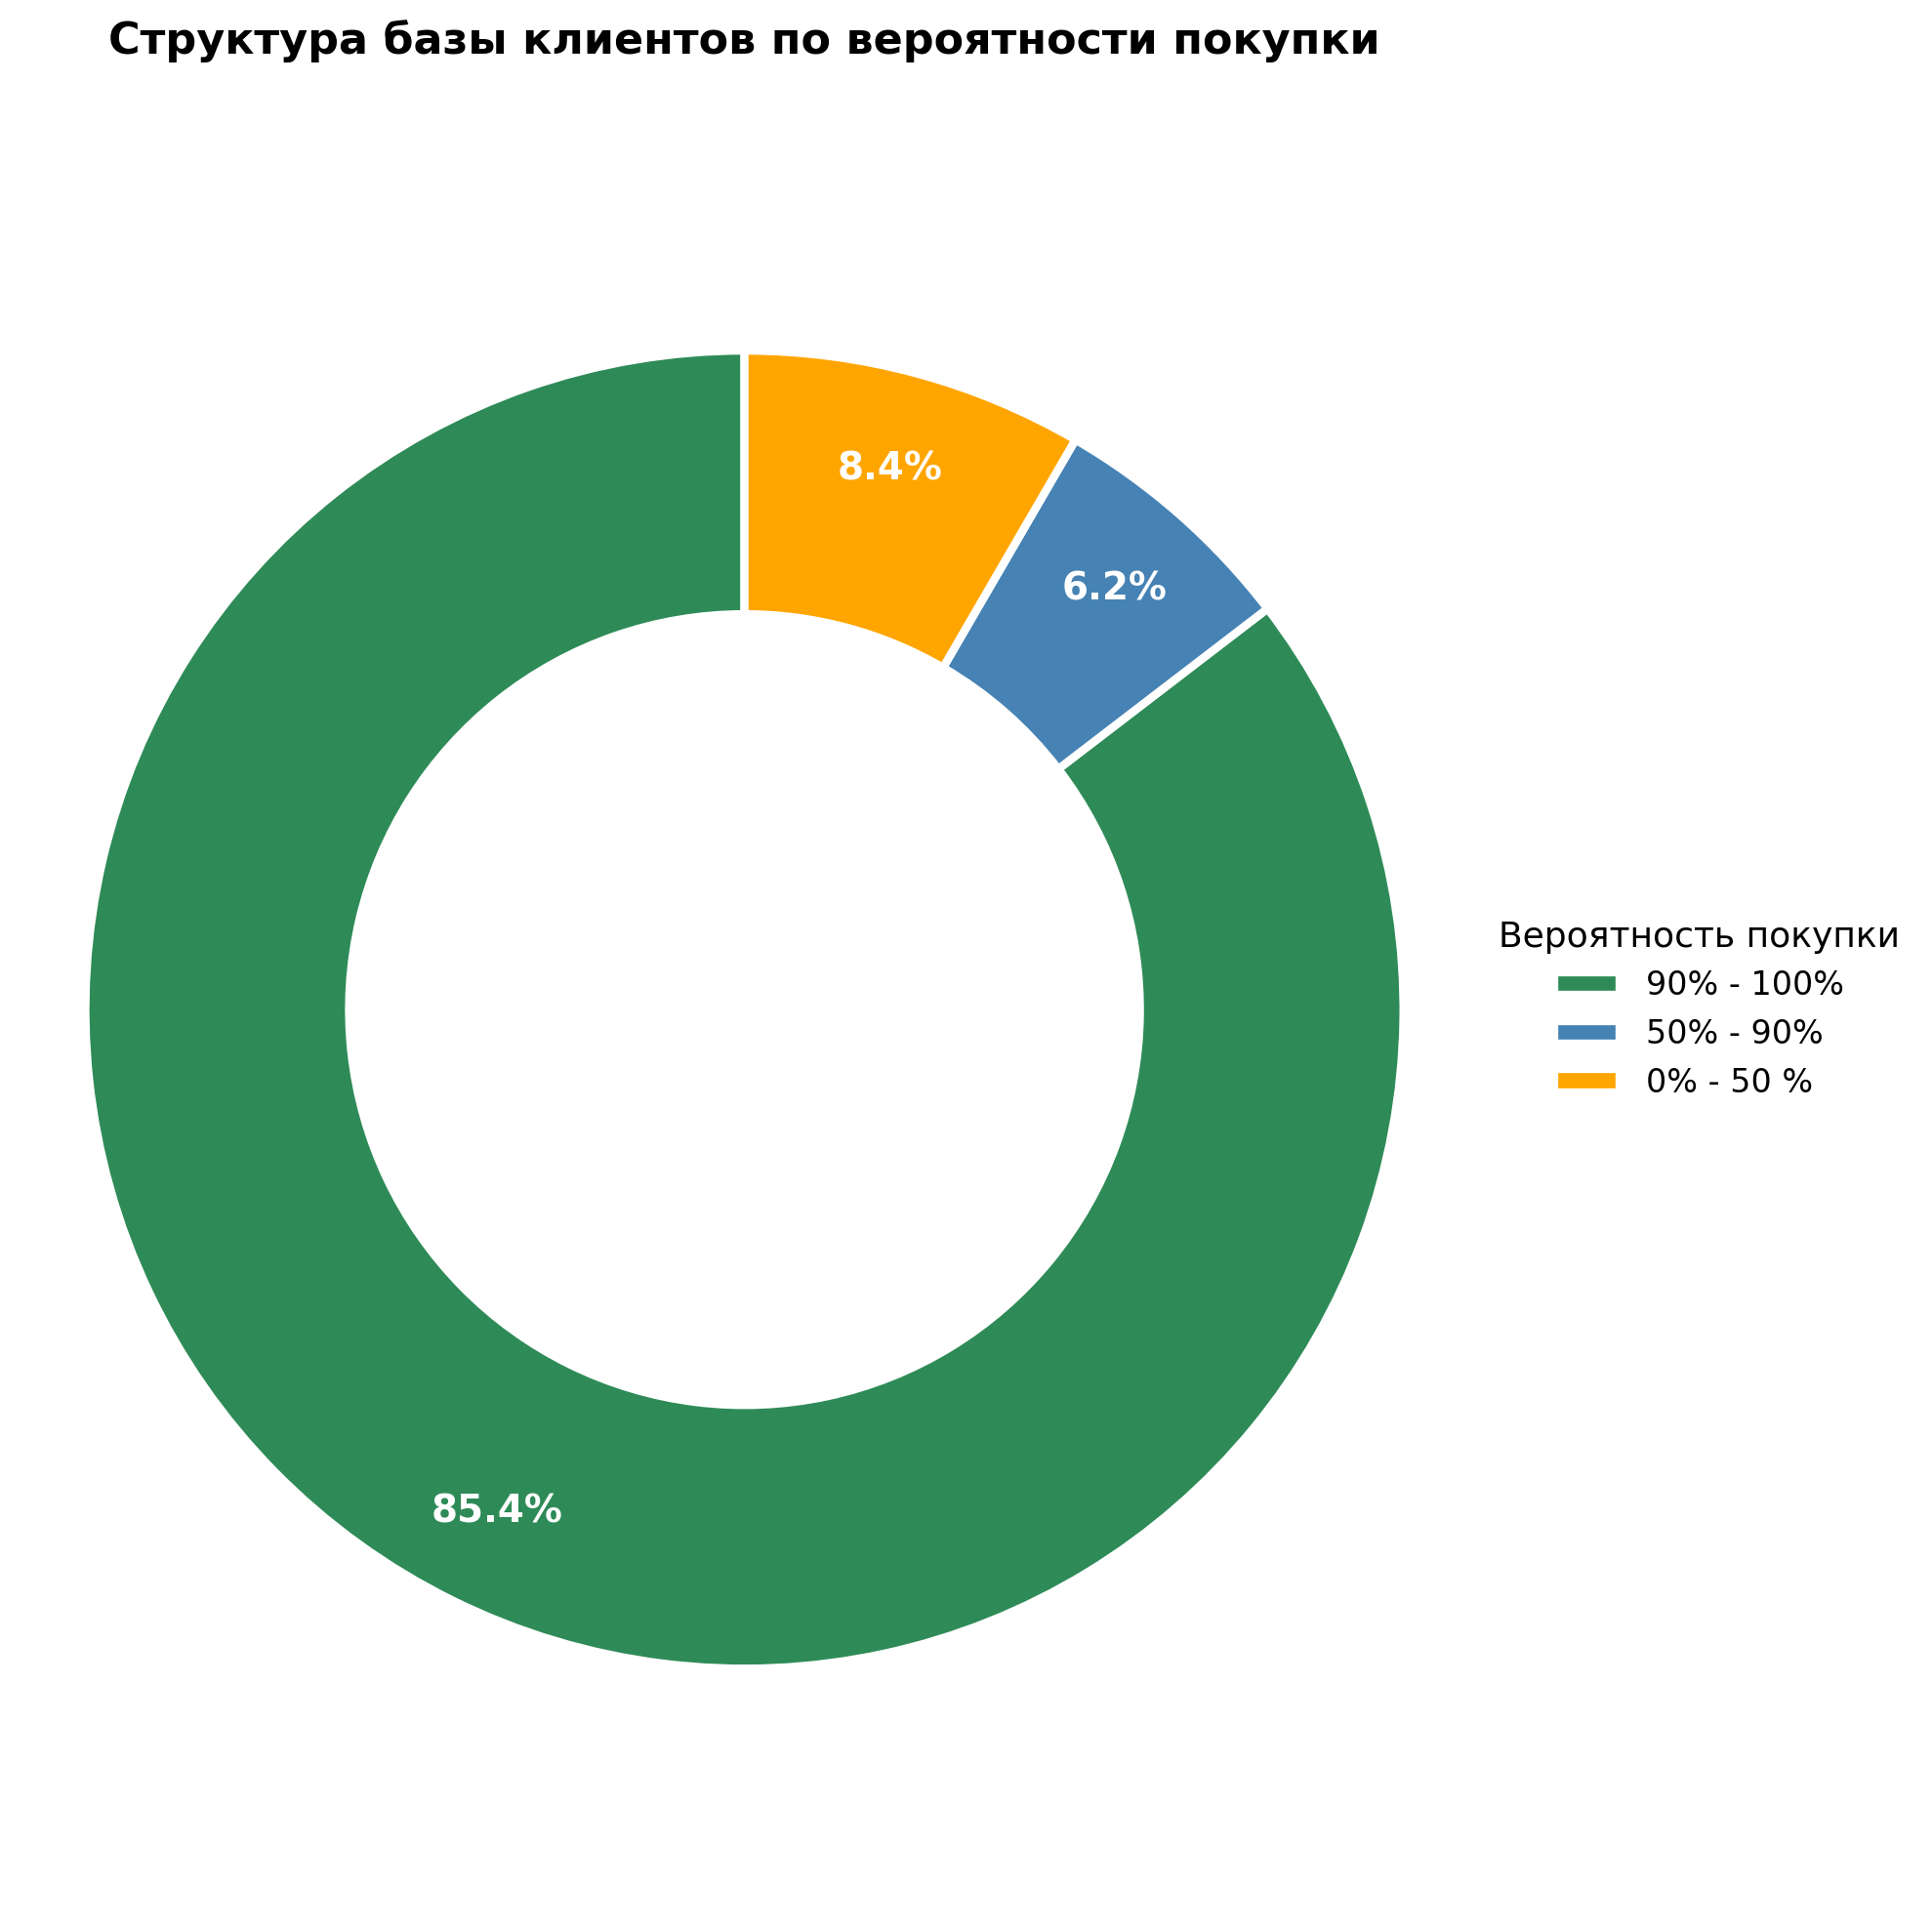

In [22]:
df_ml1_copy = df_ml1.copy()

df_ml1_copy['Группа_вероятности'] = pd.cut(
    df_ml1_copy['Вероятность_покупки_неделя_%'],
    bins=[0, 50, 90, 100],
    labels=['0% - 50 %', '50% - 90%', '90% - 100%'],
    include_lowest=True,
    right=True
)

df_grouped = (
    df_ml1_copy
    .groupby('Группа_вероятности', as_index=False, observed=True)
    .size()
    .rename(columns={'size': 'Количество_клиентов'})
)
df_grouped['Процент_группы'] = (df_grouped['Количество_клиентов'] / len(df_ml1)) * 100

# Фиксируем порядок категорий, чтобы график и легенда не "плясали" 
# Задаем желаемый порядок: от самых горячих к самым холодным
desired_order = ['90% - 100%', '50% - 90%', '0% - 50 %']

# Превращаем колонку в категориальную с явным порядком
df_grouped['Группа_вероятности'] = pd.Categorical(
    df_grouped['Группа_вероятности'],
    categories=desired_order,
    ordered=True
)

# Сортируем DataFrame согласно этому порядку
df_grouped = df_grouped.sort_values('Группа_вероятности')
display(df_grouped)

# Теперь берем данные - они гарантированно идут в нужном порядке
labels = df_grouped['Группа_вероятности'].tolist()
sizes = df_grouped['Количество_клиентов'].tolist()

# Цвета строго в том же порядке, что и desired_order:
# 1. Зеленый (90-100%)
# 2. Синий (50-90%)
# 3. Оранжевый (0-50%)
colors = ['#2E8B57', '#4682B4', '#FFA500'] 

# --- Рисуем график ---
fig, ax = plt.subplots(figsize=(10, 10))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=3)
)

# Стилизация процентов
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_weight('bold')
    autotext.set_fontsize(14)

# Легенда (теперь она 100% совпадает с цветами, так как порядок wedges и labels синхронизирован)
ax.legend(
    wedges,
    labels,
    title="Вероятность покупки",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    frameon=False,
    fontsize=12,
    title_fontsize=13
)

ax.set_title('Структура базы клиентов по вероятности покупки', fontsize=16, pad=20, fontweight='bold')
ax.axis('equal')
plt.tight_layout()
plt.show()


#### Результаты:
Мы получили, что ~ 85% всех клиентов совершат покупку в течении 7 дней.
#### Результаты ML:
Группы:\
0 - не купит в течении 7 дней\
1 - купит в течении 7 дней(целевая группа)
1) Precision (точность) = 0,97 (97 %) — означает, что модель ошибается лишь в 3 % случаев при выборе, купит клиент или нет.
2) Recall (полнота) = 0,99 (99 %) — модель почти не пропускает реальных покупателей: она находит 99 % тех, кто действительно купит.
3) F1‑score (гармоническое среднее) = 0,98 (98 %) — баланс между precision и recall.
4) Support (поддержка, количество объектов) = 1150 — сколько реальных примеров класса «Купит через неделю» было в выборке, по которой считали метрики.
5) Accuracy (доля правильных ответов) = 0,96 (96 %) — 96 % всех предсказаний модель сделала правильно.
6) ROC‑AUC (способность модели разделять классы по вероятностям) = ~0,99 (99 %) — модель очень хорошо ранжирует клиентов по вероятности покупки.


#### Выводы (какие признаки влияют чаще всего на последующую покупку):
1) Самый значимый признак в нашей модели — это F (частота): чем чаще клиент покупает, тем выше вероятность, что он купит в ближайшие 7 дней.
2) Самый слабый признак — это Количество_купленных_товаров: модель считает, что количество купленных товаров никак не влияет на следующую покупку. Значит, есть клиенты, которые покупают мало, но часто, или много, но редко.
3) R (давность) и M (выручка) имеют среднее влияние на покупку в ближайшие 7 дней. Обычно всегда: чем больше выручка, тем чаще заказы, но такая формулировка подходит только к розничным клиентам; оптовые клиенты ведут себя по‑другому.\
Интересный паттерн поведения — это почему с ростом дней последнего заказа растёт вероятность покупки в будущем. Я думаю, это связано с тем, что в последнее время в магазин приходило не так много новых клиентов; за счёт этого доля постоянных со временем стала расти.

#### Линейная регресия

##### Доп очистка для линейной регресии


##### Для регрессий любых типов принято давать максимально чистые данные.
Любая аномалия в данных может испортить модель.
Чтобы избежать неправильного прогноза, удалим все выбросы из таблицы, полученной логистической регрессией.
Результатом машинного обучения мы получим прогноз величины следующей покупки.


In [23]:
df_work = df_ml1.copy()

# 1. Убираем пропуски ТОЛЬКО в колонках для сегментации
df_work = df_work.dropna(subset=['Сегмент_товаров', 'Сегмент_объемов'])

# 2. Группируем по паре сегментов и считаем количество строк (транзакций)
df_seg_agg = (
    df_work
    .groupby(['Сегмент_товаров', 'Сегмент_объемов'], as_index=False, observed=False)
    .size()
)
display(df_seg_agg)
# 3. Фильтруем: оставляем только сегменты, где больше 1500 транзакций,остальное считаем выбросами
df_filtered = df_seg_agg[df_seg_agg['size'] > 1500]

# 4. Теперь берём уникальные значения уже из отфильтрованной таблицы
a = df_filtered['Сегмент_товаров'].unique()
b = df_filtered['Сегмент_объемов'].unique()
print('Уникальные сегменты товаров:',a)
print('Уникальные сегменты объёмов:',b)

df_final = df_work.copy()

# Оставляем строки, где Сегмент_товаров есть в списке a И Сегмент_объемов есть в списке b
mask = (
    df_final['Сегмент_товаров'].isin(a) &
    df_final['Сегмент_объемов'].isin(b)
)
df_final = df_final[mask]

display(df_final)

,Сегмент_товаров,Сегмент_объемов,size
0,Бюджетный,Розничный,2241
1,Бюджетный,Мелкий_опт,1889
2,Бюджетный,Средний_опт,69
3,Бюджетный,Крупный_опт,1
4,Средний,Розничный,36
5,Средний,Мелкий_опт,22
6,Средний,Средний_опт,2
7,Средний,Крупный_опт,0
8,Премиум,Розничный,1
9,Премиум,Мелкий_опт,1


Уникальные сегменты товаров: ['Бюджетный']
Categories (4, object): ['Бюджетный' < 'Средний' < 'Премиум' < 'Ультра']
Уникальные сегменты объёмов: ['Розничный', 'Мелкий_опт']
Categories (4, object): ['Розничный' < 'Мелкий_опт' < 'Средний_опт' < 'Крупный_опт']


,ID_покупателя,Итоговая_выручка,Средний_чек,Количество_заказов,Количество_купленных_товаров,Количество_вернувших_товаров,Доля_выкупа_%,Средняя_цена_товара,Среднее_количество_выкупленных_товаров,Сегмент_товаров,...,M,RFM_score,Сегмент_RFM,Доля_накопленная,Сегмент_ABC,Сегмент_качество,Сколько_дней_клиент,Средний_интервал_дней,Купит_через_неделю,Вероятность_покупки_неделя_%
0,14646.0,2.701761e+05,1.301426e+02,2076,189907.0,292.0,99.846241,2.598738,91.336705,Бюджетный,...,4,12,Лучшие,0.032672,A,Надёжный,354,0.169866,1,100.000000
3,14911.0,1.333635e+05,2.264621e+01,5889,80238.0,2565.0,96.803260,4.121768,13.189506,Бюджетный,...,4,12,Лучшие,0.100569,A,Стандартный,373,0.063253,1,99.999996
4,12415.0,1.237254e+05,1.594400e+02,776,77374.0,428.0,99.446843,3.221418,99.157216,Бюджетный,...,4,11,Лучшие,0.115530,A,Надёжный,314,0.404118,1,99.999999
5,14156.0,1.129842e+05,7.990395e+01,1414,56328.0,860.0,98.473228,4.621768,39.227723,Бюджетный,...,4,12,Лучшие,0.129193,A,Стандартный,363,0.256719,1,99.999928
6,17511.0,8.812538e+04,8.190091e+01,1076,64549.0,1537.0,97.618863,2.422937,58.561338,Бюджетный,...,4,12,Лучшие,0.139850,A,Стандартный,371,0.345116,1,99.999967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4313,18274.0,1.776357e-15,8.074349e-17,22,88.0,88.0,0.000000,3.671818,0.000000,Бюджетный,...,1,6,Спящие,1.000000,C,Бан,13,0.619048,1,99.997624
4315,16878.0,0.000000e+00,0.000000e+00,6,12.0,12.0,0.000000,1.583333,0.000000,Бюджетный,...,1,5,Спящие,1.000000,C,Бан,60,12.000000,0,90.082951
4316,13364.0,0.000000e+00,0.000000e+00,20,71.0,71.0,0.000000,2.598000,0.000000,Бюджетный,...,1,5,Спящие,1.000000,C,Бан,5,0.263158,1,99.997749
4317,14557.0,0.000000e+00,0.000000e+00,32,510.0,510.0,0.000000,1.590000,0.000000,Бюджетный,...,1,5,Спящие,1.000000,C,Бан,22,0.709677,1,99.995306


#### Тепловая карта распределения транзакций.

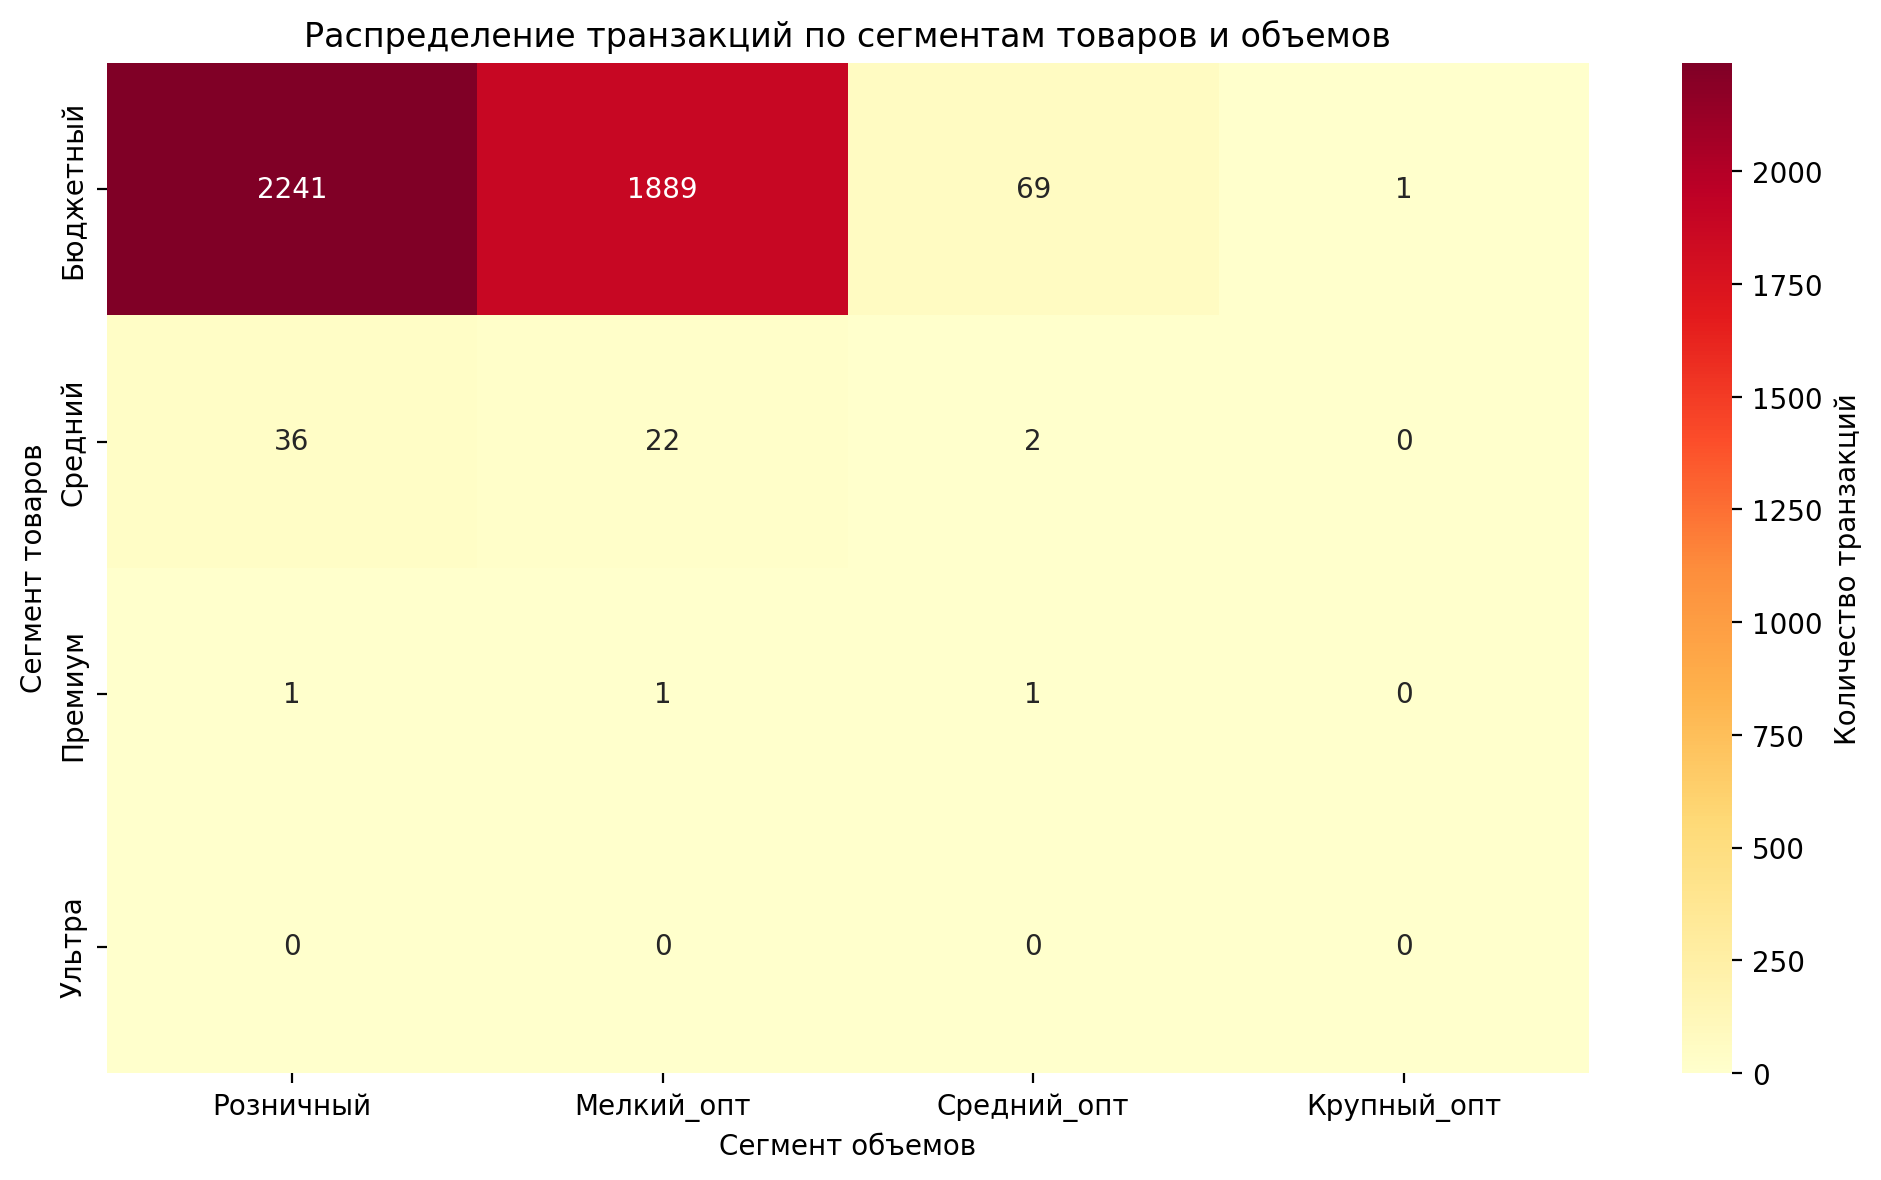

In [24]:
# Преобразуем данные в матрицу для heatmap
pivot_df = df_seg_agg.pivot(index='Сегмент_товаров', columns='Сегмент_объемов', values='size')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Количество транзакций'})
plt.title('Распределение транзакций по сегментам товаров и объемов')
plt.xlabel('Сегмент объемов')
plt.ylabel('Сегмент товаров')
plt.tight_layout()
plt.show()


#### Результаты:
Получить хорошие результаты ML могут только две самые большие группы по объему Розничный и Мелкий_опт, если оставить остальные модель будет чаще ошибаться

#### Другая подготовка модели. 
Чтобы не было аномалий в объемах покупок разделим датафрейм на два.
Retail(розничные покупатели) и Wholesale(это оптовые)


In [25]:
#Отберем клиентов которые приносят 80 процентов всей выручки
df_retail = df_final.loc[df_final['Сегмент_объемов'] ==  'Розничный']
df_wholesale = df_final.loc[df_final['Сегмент_объемов'] !=  'Розничный']
display(df_retail)    
display(df_wholesale)




,ID_покупателя,Итоговая_выручка,Средний_чек,Количество_заказов,Количество_купленных_товаров,Количество_вернувших_товаров,Доля_выкупа_%,Средняя_цена_товара,Среднее_количество_выкупленных_товаров,Сегмент_товаров,...,M,RFM_score,Сегмент_RFM,Доля_накопленная,Сегмент_ABC,Сегмент_качество,Сколько_дней_клиент,Средний_интервал_дней,Купит_через_неделю,Вероятность_покупки_неделя_%
16,14096.0,5.122447e+04,9.996969e+00,5124,16348.0,17.0,99.896012,6.924256,3.187158,Бюджетный,...,4,12,Лучшие,0.208694,A,Надёжный,98,0.019114,1,100.000000
18,17841.0,3.986905e+04,5.103565e+00,7812,22834.0,206.0,99.097837,2.554579,2.896569,Бюджетный,...,4,12,Лучшие,0.219612,A,Надёжный,372,0.047625,1,99.989473
27,12748.0,3.047440e+04,6.840494e+00,4455,25287.0,1059.0,95.812077,2.888321,5.438384,Бюджетный,...,4,12,Лучшие,0.256819,A,Стандартный,373,0.083670,1,99.992349
39,15039.0,1.963859e+04,1.324247e+01,1483,9131.0,18.0,99.802869,3.206082,6.144976,Бюджетный,...,4,12,Лучшие,0.291449,A,Надёжный,360,0.242915,1,99.960905
75,14606.0,1.163335e+04,4.216510e+00,2759,6187.0,246.0,96.023921,2.819304,2.153316,Бюджетный,...,4,12,Лучшие,0.354323,A,Стандартный,373,0.135243,1,99.896521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4313,18274.0,1.776357e-15,8.074349e-17,22,88.0,88.0,0.000000,3.671818,0.000000,Бюджетный,...,1,6,Спящие,1.000000,C,Бан,13,0.619048,1,99.997624
4315,16878.0,0.000000e+00,0.000000e+00,6,12.0,12.0,0.000000,1.583333,0.000000,Бюджетный,...,1,5,Спящие,1.000000,C,Бан,60,12.000000,0,90.082951
4316,13364.0,0.000000e+00,0.000000e+00,20,71.0,71.0,0.000000,2.598000,0.000000,Бюджетный,...,1,5,Спящие,1.000000,C,Бан,5,0.263158,1,99.997749
4317,14557.0,0.000000e+00,0.000000e+00,32,510.0,510.0,0.000000,1.590000,0.000000,Бюджетный,...,1,5,Спящие,1.000000,C,Бан,22,0.709677,1,99.995306


,ID_покупателя,Итоговая_выручка,Средний_чек,Количество_заказов,Количество_купленных_товаров,Количество_вернувших_товаров,Доля_выкупа_%,Средняя_цена_товара,Среднее_количество_выкупленных_товаров,Сегмент_товаров,...,M,RFM_score,Сегмент_RFM,Доля_накопленная,Сегмент_ABC,Сегмент_качество,Сколько_дней_клиент,Средний_интервал_дней,Купит_через_неделю,Вероятность_покупки_неделя_%
0,14646.0,270176.06,130.142611,2076,189907.0,292.0,99.846241,2.598738,91.336705,Бюджетный,...,4,12,Лучшие,0.032672,A,Надёжный,354,0.169866,1,100.000000
3,14911.0,133363.53,22.646210,5889,80238.0,2565.0,96.803260,4.121768,13.189506,Бюджетный,...,4,12,Лучшие,0.100569,A,Стандартный,373,0.063253,1,99.999996
4,12415.0,123725.45,159.440013,776,77374.0,428.0,99.446843,3.221418,99.157216,Бюджетный,...,4,11,Лучшие,0.115530,A,Надёжный,314,0.404118,1,99.999999
5,14156.0,112984.19,79.903953,1414,56328.0,860.0,98.473228,4.621768,39.227723,Бюджетный,...,4,12,Лучшие,0.129193,A,Стандартный,363,0.256719,1,99.999928
6,17511.0,88125.38,81.900911,1076,64549.0,1537.0,97.618863,2.422937,58.561338,Бюджетный,...,4,12,Лучшие,0.139850,A,Стандартный,371,0.345116,1,99.999967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4280,14300.0,43.20,14.400000,3,32.0,0.0,100.000000,1.383333,10.666667,Бюджетный,...,1,5,Спящие,0.999898,C,Надёжный,1,0.500000,1,97.986787
4283,15178.0,40.50,13.500000,3,30.0,0.0,100.000000,1.350000,10.000000,Бюджетный,...,1,3,Потерянные,0.999913,C,Надёжный,1,0.500000,1,96.079753
4286,16659.0,39.12,19.560000,2,72.0,0.0,100.000000,0.620000,36.000000,Бюджетный,...,1,3,Потерянные,0.999928,C,Надёжный,1,1.000000,1,96.150741
4288,12855.0,38.10,12.700000,3,30.0,0.0,100.000000,1.550000,10.000000,Бюджетный,...,1,3,Потерянные,0.999937,C,Надёжный,1,0.500000,1,96.066667


#### Поиск аномалий в среднем чеке
Доп очистка для целевой переменной

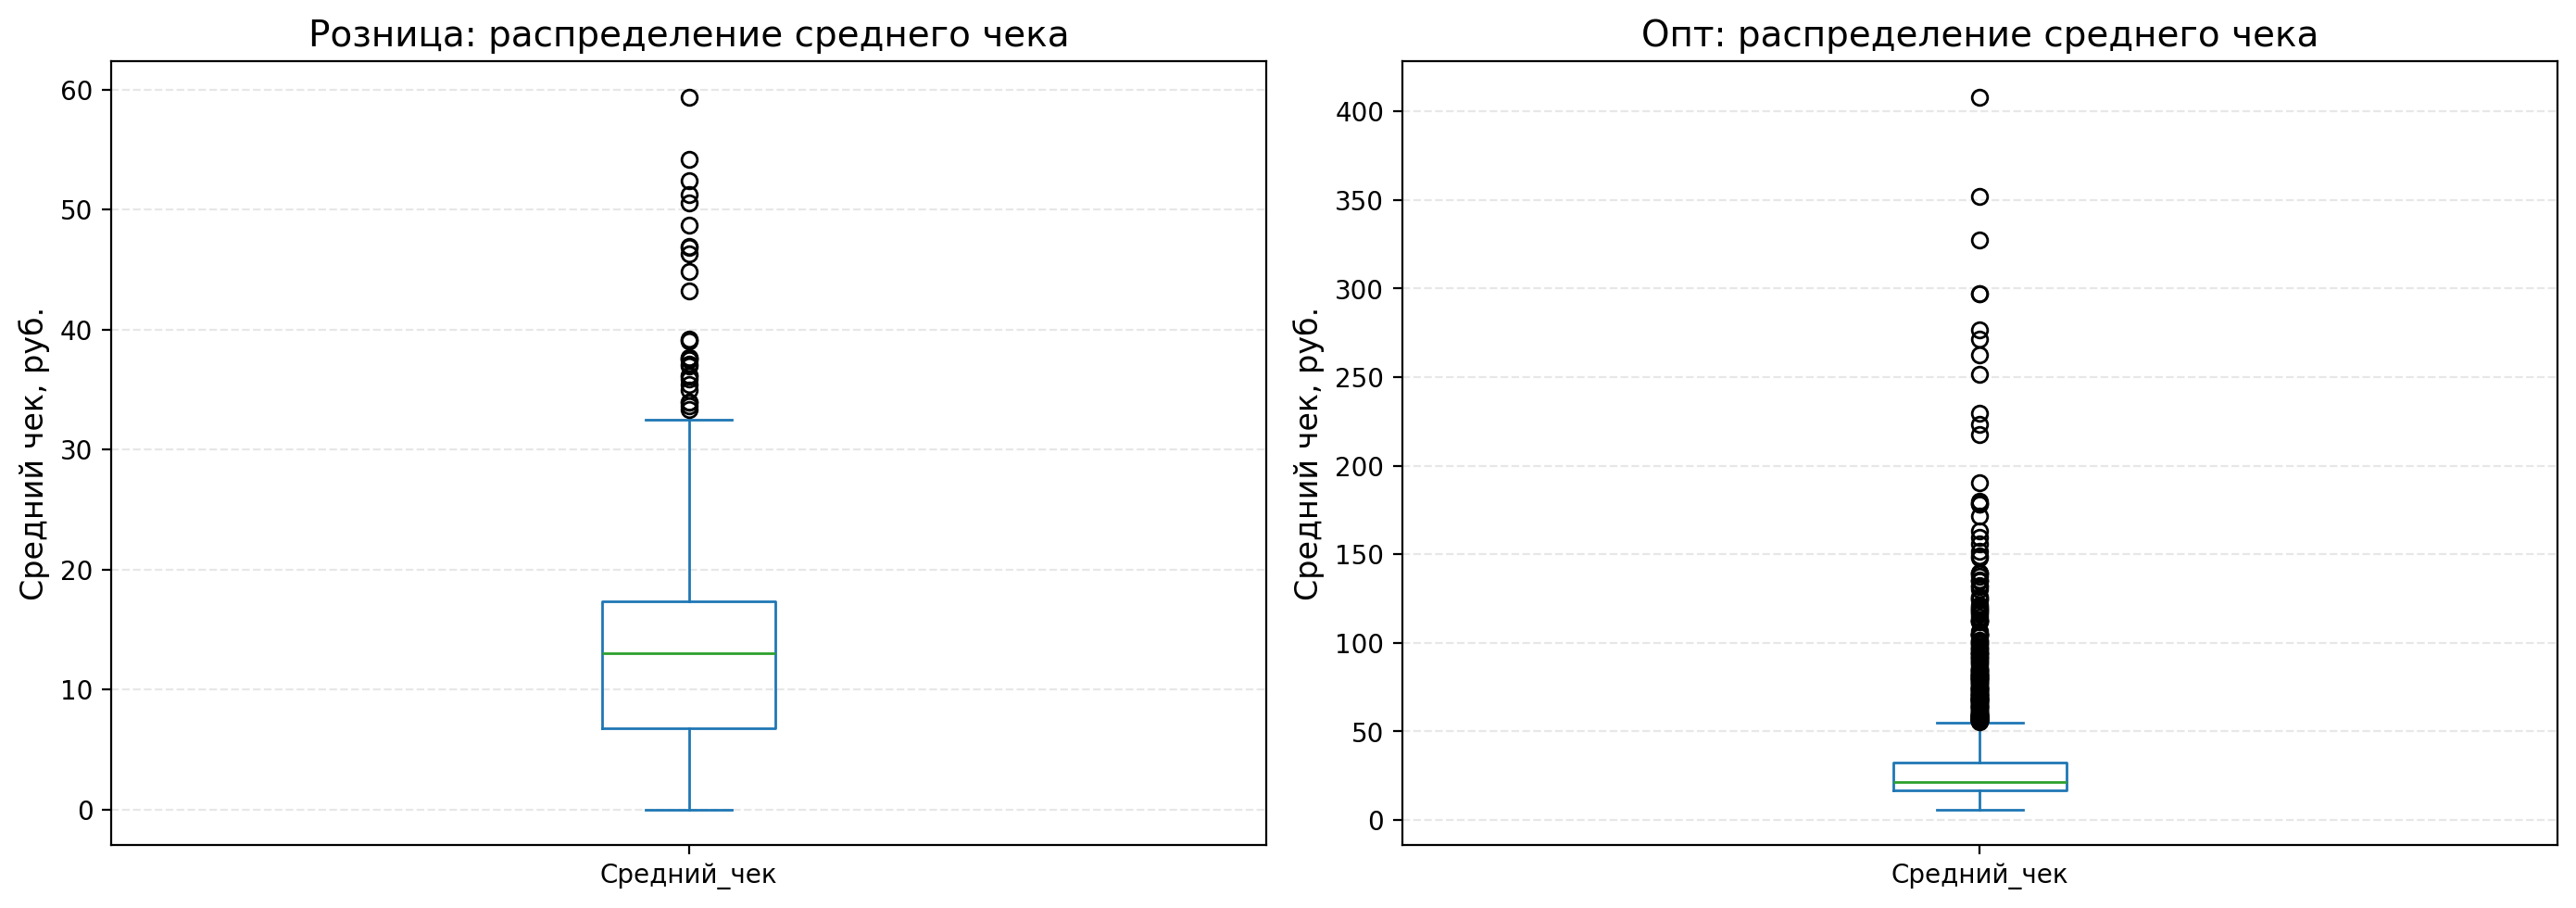

--- Розница ---
Медиана: 13.03 руб.
Q1: 6.73, Q3: 17.33
Верхняя граница выбросов: 33.24 руб.
Доля клиентов-выбросов (выше границы): 1.29%

--- Опт ---
Медиана: 21.35 руб.
Q1: 16.69, Q3: 32.22
Верхняя граница выбросов: 55.51 руб.
Доля клиентов-выбросов (выше границы): 11.49%



,ID_покупателя,Итоговая_выручка,Средний_чек,Количество_заказов,Количество_купленных_товаров,Количество_вернувших_товаров,Доля_выкупа_%,Средняя_цена_товара,Среднее_количество_выкупленных_товаров,Сегмент_товаров,...,M,RFM_score,Сегмент_RFM,Доля_накопленная,Сегмент_ABC,Сегмент_качество,Сколько_дней_клиент,Средний_интервал_дней,Купит_через_неделю,Вероятность_покупки_неделя_%
16,14096.0,5.122447e+04,9.996969e+00,5124,16348.0,17.0,99.896012,6.924256,3.187158,Бюджетный,...,4,12,Лучшие,0.208694,A,Надёжный,98,0.019114,1,100.000000
18,17841.0,3.986905e+04,5.103565e+00,7812,22834.0,206.0,99.097837,2.554579,2.896569,Бюджетный,...,4,12,Лучшие,0.219612,A,Надёжный,372,0.047625,1,99.989473
27,12748.0,3.047440e+04,6.840494e+00,4455,25287.0,1059.0,95.812077,2.888321,5.438384,Бюджетный,...,4,12,Лучшие,0.256819,A,Стандартный,373,0.083670,1,99.992349
39,15039.0,1.963859e+04,1.324247e+01,1483,9131.0,18.0,99.802869,3.206082,6.144976,Бюджетный,...,4,12,Лучшие,0.291449,A,Надёжный,360,0.242915,1,99.960905
75,14606.0,1.163335e+04,4.216510e+00,2759,6187.0,246.0,96.023921,2.819304,2.153316,Бюджетный,...,4,12,Лучшие,0.354323,A,Стандартный,373,0.135243,1,99.896521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4313,18274.0,1.776357e-15,8.074349e-17,22,88.0,88.0,0.000000,3.671818,0.000000,Бюджетный,...,1,6,Спящие,1.000000,C,Бан,13,0.619048,1,99.997624
4315,16878.0,0.000000e+00,0.000000e+00,6,12.0,12.0,0.000000,1.583333,0.000000,Бюджетный,...,1,5,Спящие,1.000000,C,Бан,60,12.000000,0,90.082951
4316,13364.0,0.000000e+00,0.000000e+00,20,71.0,71.0,0.000000,2.598000,0.000000,Бюджетный,...,1,5,Спящие,1.000000,C,Бан,5,0.263158,1,99.997749
4317,14557.0,0.000000e+00,0.000000e+00,32,510.0,510.0,0.000000,1.590000,0.000000,Бюджетный,...,1,5,Спящие,1.000000,C,Бан,22,0.709677,1,99.995306


,ID_покупателя,Итоговая_выручка,Средний_чек,Количество_заказов,Количество_купленных_товаров,Количество_вернувших_товаров,Доля_выкупа_%,Средняя_цена_товара,Среднее_количество_выкупленных_товаров,Сегмент_товаров,...,M,RFM_score,Сегмент_RFM,Доля_накопленная,Сегмент_ABC,Сегмент_качество,Сколько_дней_клиент,Средний_интервал_дней,Купит_через_неделю,Вероятность_покупки_неделя_%
3,14911.0,133363.53,22.646210,5889,80238.0,2565.0,96.803260,4.121768,13.189506,Бюджетный,...,4,12,Лучшие,0.100569,A,Стандартный,373,0.063253,1,99.999996
10,15311.0,59284.19,23.924209,2478,38147.0,474.0,98.757438,2.520218,15.202986,Бюджетный,...,4,12,Лучшие,0.169861,A,Стандартный,374,0.150989,1,99.998576
11,13089.0,57322.13,30.934771,1853,31025.0,283.0,99.087832,2.782380,16.590394,Бюджетный,...,4,12,Лучшие,0.176793,A,Надёжный,367,0.198164,1,99.997289
15,14298.0,51499.94,31.421562,1639,58343.0,72.0,99.876592,1.496614,35.552776,Бюджетный,...,4,12,Лучшие,0.202499,A,Надёжный,358,0.218426,1,99.999958
28,13098.0,28658.88,47.370050,605,15968.0,57.0,99.643036,2.832397,26.299174,Бюджетный,...,4,12,Лучшие,0.260285,A,Надёжный,317,0.524834,1,99.998052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4280,14300.0,43.20,14.400000,3,32.0,0.0,100.000000,1.383333,10.666667,Бюджетный,...,1,5,Спящие,0.999898,C,Надёжный,1,0.500000,1,97.986787
4283,15178.0,40.50,13.500000,3,30.0,0.0,100.000000,1.350000,10.000000,Бюджетный,...,1,3,Потерянные,0.999913,C,Надёжный,1,0.500000,1,96.079753
4286,16659.0,39.12,19.560000,2,72.0,0.0,100.000000,0.620000,36.000000,Бюджетный,...,1,3,Потерянные,0.999928,C,Надёжный,1,1.000000,1,96.150741
4288,12855.0,38.10,12.700000,3,30.0,0.0,100.000000,1.550000,10.000000,Бюджетный,...,1,3,Потерянные,0.999937,C,Надёжный,1,0.500000,1,96.066667


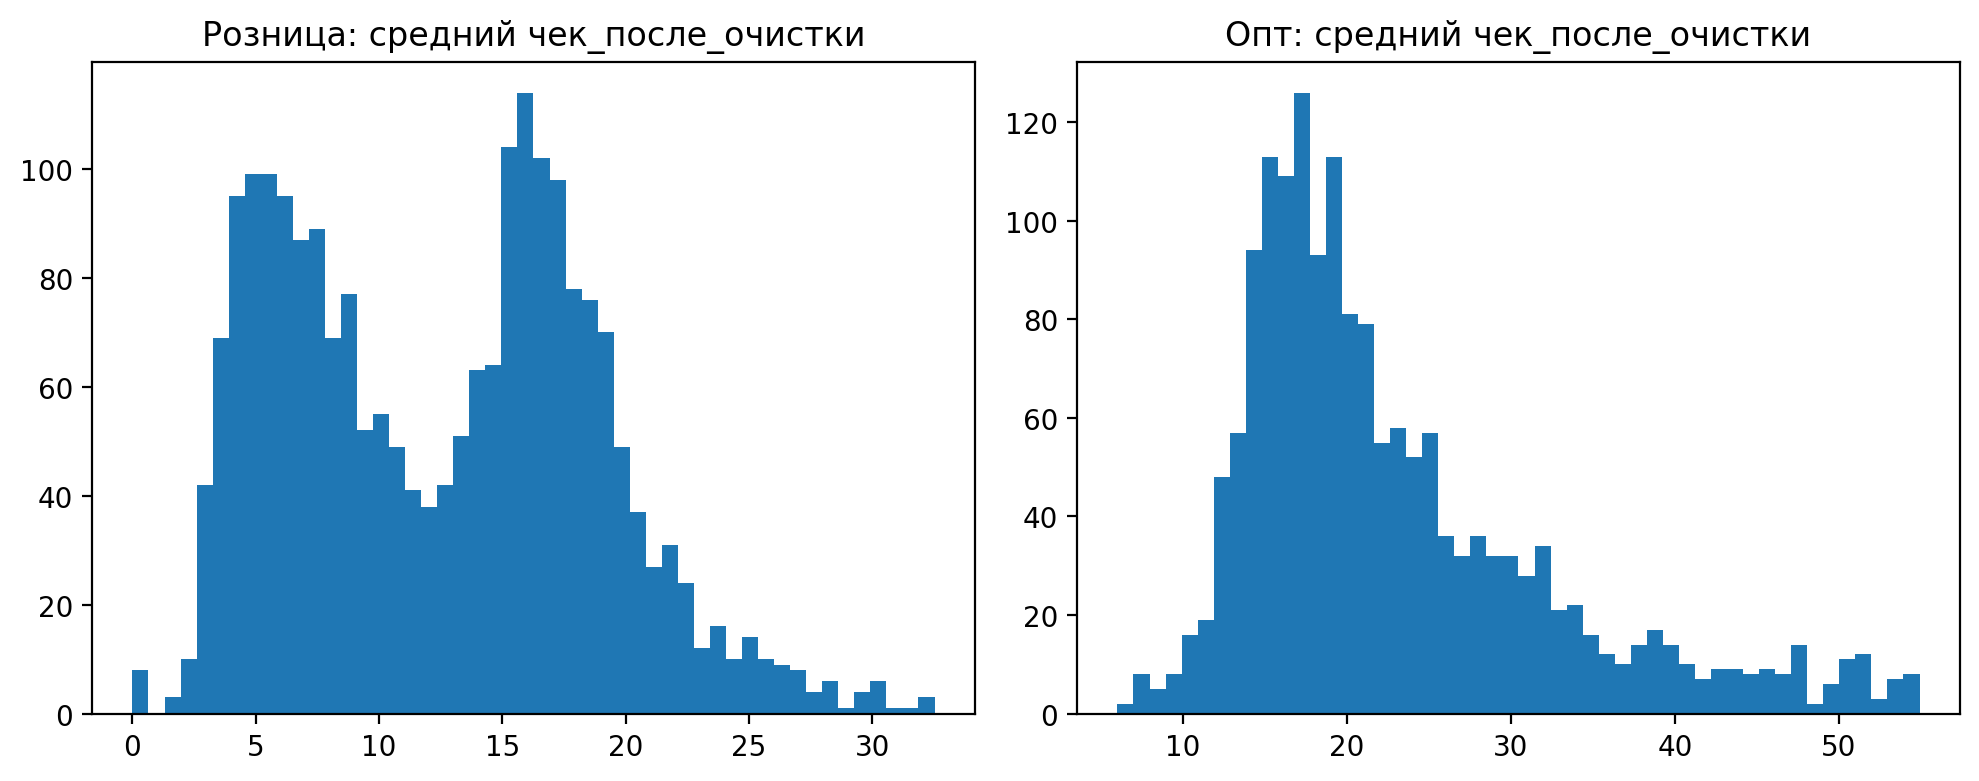

In [26]:
# Создаём фигуру с двумя подграфиками (1 строка, 2 столбца)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # ширина побольше, чтобы оба графика влезли

# --- График 1: Розница (слева) ---
ax_retail = df_retail['Средний_чек'].plot.box(ax=axes[0])
ax_retail.set_title('Розница: распределение среднего чека', fontsize=14)
ax_retail.set_ylabel('Средний чек, руб.', fontsize=12)
ax_retail.grid(axis='y', linestyle='--', alpha=0.3)

# --- График 2: Опт (справа) ---
ax_wholesale = df_wholesale['Средний_чек'].plot.box(ax=axes[1])
ax_wholesale.set_title('Опт: распределение среднего чека', fontsize=14)
ax_wholesale.set_ylabel('Средний чек, руб.', fontsize=12)  # можно оставить или убрать, если мешает
ax_wholesale.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()  # чтобы подписи и заголовки не наезжали друг на друга
plt.show()

def analyze_distribution(series, name):
    q1 = series.quantile(0.25)
    median = series.median()
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    outlier_share = (series > upper_bound).mean()
    
    print(f"--- {name} ---")
    print(f"Медиана: {median:,.2f} руб.")
    print(f"Q1: {q1:,.2f}, Q3: {q3:,.2f}")
    print(f"Верхняя граница выбросов: {upper_bound:,.2f} руб.")
    print(f"Доля клиентов-выбросов (выше границы): {outlier_share:.2%}")
    print()

analyze_distribution(df_retail['Средний_чек'], "Розница")
analyze_distribution(df_wholesale['Средний_чек'], "Опт")

# Оставим строки где средний чек ниже или равен верхней границы выбросов
df_retail_clean = df_retail[df_retail['Средний_чек'] <= 33.24].copy()
#df_retail = df_retail_clean
# Опт: оставляем строки, где Средний_чек <= 55.51
df_wholesale_clean = df_wholesale[df_wholesale['Средний_чек'] <= 55.51].copy()
#df_wholesale = df_wholesale_clean
display(df_retail_clean)
display(df_wholesale_clean)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df_retail_clean['Средний_чек'], bins=50)
plt.title('Розница: средний чек_после_очистки')
plt.subplot(1,2,2)
plt.hist(df_wholesale_clean['Средний_чек'], bins=50)
plt.title('Опт: средний чек_после_очистки')
plt.tight_layout()
plt.show()

#### Результаты:
Очистка целевой переменной убирает 1.29% с розничных покупаелей и 11.49% с оптовых.\
Оставшиеся клиенты показывают типичное поведение для своей группы.

#### Линейная регресия с логарифмированием(чтобы избежать ненужных искажений)

##### Розничные


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# --- ШАГ 1: Разделяем клиентов, а не строки ---
# Получаем уникальные ID клиентов
client_ids = df_retail_clean['ID_покупателя'].unique()

# Делим именно ID, а не датафрейм
train_ids, test_ids = train_test_split(
    client_ids, 
    test_size=0.2, 
    random_state=42
)

# Теперь собираем train и test датафреймы по этим ID
train = df_retail_clean[df_retail_clean['ID_покупателя'].isin(train_ids)].copy()
test = df_retail_clean[df_retail_clean['ID_покупателя'].isin(test_ids)].copy()

print(f"Клиентов в обучении: {len(train_ids)}, в тесте: {len(test_ids)}")
print(f"Строк в обучении: {len(train)}, в тесте: {len(test)}")

# --- ШАГ 2: Выбираем признаки и целевую переменную ---
feature_cols = [
    'R',
    'M',
    'F',
    'Доля_выкупа_%',
    'Среднее_количество_выкупленных_товаров',
    'Средняя_цена_товара',
    'Сколько_дней_клиент',
    'Средний_интервал_дней'
]

target_col = 'Средний_чек'

# Формируем X и y для обучения (только из train)
X_train = train[feature_cols].copy()
y_train = train[target_col].copy()

# Формируем X и y для теста (только из test)
X_test = test[feature_cols].copy()
y_test = test[target_col].copy()

# --- ШАГ 3: Логарифмирование (делаем отдельно на train и test) ---
# Важно: log1p считаем от реальных значений, которые у нас уже разделены
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# --- ШАГ 5: Обучение модели ---
model_lin_reg = LinearRegression()
model_lin_reg.fit(X_train, y_train_log)

# --- ШАГ 6: Прогноз и возврат к рублям ---
y_pred_log = model_lin_reg.predict(X_test)
y_pred = np.expm1(y_pred_log)   # Прогноз в рублях
y_test_original = np.expm1(y_test_log)  # Реальные значения в рублях

# --- ШАГ 7: Метрики (считаем на рублях) ---
mae_retail = mean_absolute_error(y_test_original, y_pred)
median_error_retail = np.median(np.abs(y_test_original - y_pred))
r2_retail = r2_score(y_test_original, y_pred)

print("MAE (средняя ошибка в рублях):", mae_retail)
print("Median Error (ошибка у типичного клиента):", median_error_retail)
print("R^2 (доля объяснённой дисперсии):", r2_retail)

# --- ШАГ 8: Коэффициенты модели ---
coef_retail = pd.DataFrame({
    'Признак': feature_cols,
    'Коэффициент': model_lin_reg.coef_
}).sort_values(by='Коэффициент', key=abs, ascending=False)

print("\nВажность признаков (по модулю коэффициента):")
display(coef_retail)

# --- ШАГ 9: Прогноз для ВСЕХ клиентов (как в твоём исходном коде) ---
# Здесь мы обучаем модель на ВСЕХ данных (train + test), чтобы получить прогноз для всех строк
X_all = df_retail_clean[feature_cols].copy()
y_all_log = np.log1p(df_retail_clean[target_col])

# Заполняем пропуски медианой по всему датасету (для финального прогноза это допустимо)
fill_all = X_all.median()
X_all = X_all.fillna(fill_all)

model_lin_reg_full_retail = LinearRegression()
model_lin_reg_full_retail.fit(X_all, y_all_log)

y_pred_full_log = model_lin_reg_full_retail.predict(X_all)
y_pred_full = np.expm1(y_pred_full_log)

df_ml_retail = df_retail_clean.copy()
df_ml_retail['Прогноз_среднего_чека'] = y_pred_full

# Можно вывести первые строки, чтобы убедиться, что колонка добавилась
display(df_ml_retail.head(10))


Клиентов в обучении: 1769, в тесте: 443
Строк в обучении: 1769, в тесте: 443
MAE (средняя ошибка в рублях): 2.084301853752886
Median Error (ошибка у типичного клиента): 1.3872210755419854
R^2 (доля объяснённой дисперсии): 0.7676781379343658

Важность признаков (по модулю коэффициента):


,Признак,Коэффициент
2,F,-0.219594
1,M,0.191877
5,Средняя_цена_товара,0.143142
4,Среднее_количество_выкупленных_товаров,0.119963
0,R,-0.019319
3,Доля_выкупа_%,0.009931
7,Средний_интервал_дней,0.004743
6,Сколько_дней_клиент,0.000092


,ID_покупателя,Итоговая_выручка,Средний_чек,Количество_заказов,Количество_купленных_товаров,Количество_вернувших_товаров,Доля_выкупа_%,Средняя_цена_товара,Среднее_количество_выкупленных_товаров,Сегмент_товаров,...,RFM_score,Сегмент_RFM,Доля_накопленная,Сегмент_ABC,Сегмент_качество,Сколько_дней_клиент,Средний_интервал_дней,Купит_через_неделю,Вероятность_покупки_неделя_%,Прогноз_среднего_чека
16,14096.0,51224.47,9.996969,5124,16348.0,17.0,99.896012,6.924256,3.187158,Бюджетный,...,12,Лучшие,0.208694,A,Надёжный,98,0.019114,1,100.000000,13.511630
18,17841.0,39869.05,5.103565,7812,22834.0,206.0,99.097837,2.554579,2.896569,Бюджетный,...,12,Лучшие,0.219612,A,Надёжный,372,0.047625,1,99.989473,6.632612
27,12748.0,30474.40,6.840494,4455,25287.0,1059.0,95.812077,2.888321,5.438384,Бюджетный,...,12,Лучшие,0.256819,A,Стандартный,373,0.083670,1,99.992349,9.527791
39,15039.0,19638.59,13.242475,1483,9131.0,18.0,99.802869,3.206082,6.144976,Бюджетный,...,12,Лучшие,0.291449,A,Надёжный,360,0.242915,1,99.960905,11.415927
75,14606.0,11633.35,4.216510,2759,6187.0,246.0,96.023921,2.819304,2.153316,Бюджетный,...,12,Лучшие,0.354323,A,Стандартный,373,0.135243,1,99.896521,6.069180
77,14194.0,11216.75,18.570778,604,5840.0,57.0,99.023973,3.365248,9.574503,Бюджетный,...,12,Лучшие,0.357080,A,Надёжный,304,0.504146,1,99.995804,17.812306
80,14895.0,11020.26,21.779170,506,4851.0,28.0,99.422799,4.217708,9.531621,Бюджетный,...,12,Лучшие,0.361094,A,Надёжный,315,0.623762,1,99.991734,20.336741
84,13319.0,10664.34,21.328680,500,4724.0,38.0,99.195597,3.378840,9.372000,Бюджетный,...,12,Лучшие,0.366299,A,Надёжный,363,0.727455,1,99.918236,17.607458
89,14769.0,10383.83,9.740929,1066,7239.0,30.0,99.585578,2.712936,6.762664,Бюджетный,...,12,Лучшие,0.372631,A,Надёжный,355,0.333333,1,99.960541,11.393639
96,17706.0,10097.37,25.562962,395,3899.0,66.0,98.307258,4.341392,9.703797,Бюджетный,...,12,Лучшие,0.381303,A,Стандартный,363,0.921320,1,99.908064,21.131944


##### Оптовые

In [28]:
# --- ШАГ 1: Разделяем клиентов, а не строки ---
# Получаем уникальные ID клиентов
client_ids = df_wholesale_clean['ID_покупателя'].unique()

# Делим именно ID, а не датафрейм
train_ids, test_ids = train_test_split(
    client_ids, 
    test_size=0.2, 
    random_state=42
)

# Теперь собираем train и test датафреймы по этим ID
train = df_wholesale_clean[df_wholesale_clean['ID_покупателя'].isin(train_ids)].copy()
test = df_wholesale_clean[df_wholesale_clean['ID_покупателя'].isin(test_ids)].copy()

print(f"Клиентов в обучении: {len(train_ids)}, в тесте: {len(test_ids)}")
print(f"Строк в обучении: {len(train)}, в тесте: {len(test)}")

# --- ШАГ 2: Выбираем признаки и целевую переменную ---
feature_cols = [
    'R',
    'M',
    'F',
    'Доля_выкупа_%',
    'Среднее_количество_выкупленных_товаров',
    'Средняя_цена_товара',
    'Сколько_дней_клиент',
    'Средний_интервал_дней'
]

target_col ='Средний_чек'

# Формируем X и y для обучения (только из train)
X_train = train[feature_cols].copy()
y_train = train[target_col].copy()

# Формируем X и y для теста (только из test)
X_test = test[feature_cols].copy()
y_test = test[target_col].copy()

# --- ШАГ 3: Логарифмирование (делаем отдельно на train и test) ---
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# --- ШАГ 5: Обучение модели ---
model_lin_reg = LinearRegression()
model_lin_reg.fit(X_train, y_train_log)

# --- ШАГ 6: Прогноз и возврат к рублям ---
y_pred_log = model_lin_reg.predict(X_test)
y_pred = np.expm1(y_pred_log)           # Прогноз в рублях
y_test_original = np.expm1(y_test_log)  # Реальные значения в рублях

# --- ШАГ 7: Метрики (считаем на рублях) ---
mae_wholesale = mean_absolute_error(y_test_original, y_pred)
median_error_wholesale = np.median(np.abs(y_test_original - y_pred))
r2_wholesale = r2_score(y_test_original, y_pred)

print("MAE (средняя ошибка в рублях):", mae_wholesale)
print("Median Error (ошибка у типичного клиента):", median_error_wholesale)
print("R^2 (доля объяснённой дисперсии):", r2_wholesale)

# --- ШАГ 8: Коэффициенты модели ---
coef_wholesale = pd.DataFrame({
    'Признак': feature_cols,
    'Коэффициент': model_lin_reg.coef_
}).sort_values(by='Коэффициент', key=abs, ascending=False)

print("\nВажность признаков (по модулю коэффициента):")
display(coef_wholesale)

# --- ШАГ 9: Прогноз для ВСЕХ клиентов ---
# Обучаем модель на ВСЕХ данных (train + test), чтобы получить прогноз для всех строк
X_all = df_wholesale_clean[feature_cols].copy()
y_all_log = np.log1p(df_wholesale_clean[target_col])

# Заполняем пропуски медианой по всему датасету
fill_all = X_all.median()
X_all = X_all.fillna(fill_all)

model_lin_reg_full_opt = LinearRegression()
model_lin_reg_full_opt.fit(X_all, y_all_log)

y_pred_full_log = model_lin_reg_full_opt.predict(X_all)
y_pred_full = np.expm1(y_pred_full_log)

df_ml_wholesale = df_wholesale_clean.copy()
df_ml_wholesale['Прогноз_среднего_чека'] = y_pred_full


display(df_ml_wholesale.head(10))



Клиентов в обучении: 1337, в тесте: 335
Строк в обучении: 1337, в тесте: 335
MAE (средняя ошибка в рублях): 4.749563363102846
Median Error (ошибка у типичного клиента): 3.067481480599156
R^2 (доля объяснённой дисперсии): 0.4645543173204546

Важность признаков (по модулю коэффициента):


,Признак,Коэффициент
1,M,0.286776
2,F,-0.257311
5,Средняя_цена_товара,0.117096
4,Среднее_количество_выкупленных_товаров,0.019753
7,Средний_интервал_дней,0.005284
0,R,-0.002610
3,Доля_выкупа_%,-0.000957
6,Сколько_дней_клиент,0.000076


,ID_покупателя,Итоговая_выручка,Средний_чек,Количество_заказов,Количество_купленных_товаров,Количество_вернувших_товаров,Доля_выкупа_%,Средняя_цена_товара,Среднее_количество_выкупленных_товаров,Сегмент_товаров,...,RFM_score,Сегмент_RFM,Доля_накопленная,Сегмент_ABC,Сегмент_качество,Сколько_дней_клиент,Средний_интервал_дней,Купит_через_неделю,Вероятность_покупки_неделя_%,Прогноз_среднего_чека
3,14911.0,133363.53,22.646210,5889,80238.0,2565.0,96.803260,4.121768,13.189506,Бюджетный,...,12,Лучшие,0.100569,A,Стандартный,373,0.063253,1,99.999996,23.650122
10,15311.0,59284.19,23.924209,2478,38147.0,474.0,98.757438,2.520218,15.202986,Бюджетный,...,12,Лучшие,0.169861,A,Стандартный,374,0.150989,1,99.998576,20.317227
11,13089.0,57322.13,30.934771,1853,31025.0,283.0,99.087832,2.782380,16.590394,Бюджетный,...,12,Лучшие,0.176793,A,Надёжный,367,0.198164,1,99.997289,21.567628
15,14298.0,51499.94,31.421562,1639,58343.0,72.0,99.876592,1.496614,35.552776,Бюджетный,...,12,Лучшие,0.202499,A,Надёжный,358,0.218426,1,99.999958,27.221125
28,13098.0,28658.88,47.370050,605,15968.0,57.0,99.643036,2.832397,26.299174,Бюджетный,...,12,Лучшие,0.260285,A,Надёжный,317,0.524834,1,99.998052,26.343913
29,13081.0,27964.48,26.456462,1057,19068.0,139.0,99.271030,2.355658,17.908231,Бюджетный,...,12,Лучшие,0.263667,A,Надёжный,370,0.349057,1,99.984102,21.063031
30,13408.0,27487.41,54.865090,501,16232.0,113.0,99.303844,3.222555,32.173653,Бюджетный,...,12,Лучшие,0.266990,A,Надёжный,372,0.744000,1,99.974022,31.352248
38,17675.0,20098.10,27.875312,721,8360.0,82.0,99.019139,3.573786,11.481276,Бюджетный,...,12,Лучшие,0.289074,A,Надёжный,367,0.509722,1,99.939705,21.387810
41,12471.0,18705.52,35.293434,530,8200.0,247.0,96.987805,4.271547,15.005660,Бюджетный,...,12,Лучшие,0.295984,A,Стандартный,371,0.701323,1,99.926399,25.040533
42,15159.0,18573.68,25.796778,720,11441.0,47.0,99.589197,2.835958,15.825000,Бюджетный,...,12,Лучшие,0.298230,A,Надёжный,360,0.500695,1,99.971777,21.371348


#### Объединение результатов линейной регресси для ритейл и оптовых покупателей 

In [29]:
df_merged_coef = pd.merge(
    coef_retail,
    coef_wholesale,
    on = 'Признак',
    how = 'inner'
)
print("MAE retail (средняя ошибка в рублях):", mae_retail)
print("Median Error retail (ошибка у типичного клиента):", median_error_retail)
print("R^2 retail (доля объяснённой дисперсии):", r2_retail)

print("MAE wholesale (средняя ошибка в рублях):", mae_wholesale)
print("Median Error wholesale (ошибка у типичного клиента):", median_error_wholesale)
print("R^2 wholesale (доля объяснённой дисперсии):", r2_wholesale)

display(df_merged_coef)

MAE retail (средняя ошибка в рублях): 2.084301853752886
Median Error retail (ошибка у типичного клиента): 1.3872210755419854
R^2 retail (доля объяснённой дисперсии): 0.7676781379343658
MAE wholesale (средняя ошибка в рублях): 4.749563363102846
Median Error wholesale (ошибка у типичного клиента): 3.067481480599156
R^2 wholesale (доля объяснённой дисперсии): 0.4645543173204546


,Признак,Коэффициент_x,Коэффициент_y
0,F,-0.219594,-0.257311
1,M,0.191877,0.286776
2,Средняя_цена_товара,0.143142,0.117096
3,Среднее_количество_выкупленных_товаров,0.119963,0.019753
4,R,-0.019319,-0.002610
5,Доля_выкупа_%,0.009931,-0.000957
6,Средний_интервал_дней,0.004743,0.005284
7,Сколько_дней_клиент,0.000092,0.000076


#### Результаты:
1) Мы получили две модели линейной регрессии с прогнозом среднего чека как для ритейл‑покупателей, так и для оптовых.
Я использовал признаки, которые так или иначе влияют на средний чек; исключить эти признаки невозможно, так как остальные признаки не имеют линейных связей с целевой переменной.
2) Самый главный фактор, влияющий на средний чек, — это Средняя_цена_товара, Среднее_количество_выкупленных_товаров (ритейл‑покупатели), выручка, что соответствует бизнес‑логике.
3) Что интересно, это количество заказов: чем больше заказов, тем меньше средний чек. Это связано с тем, что по мере того как клиент заказывает, он определяется с выбором товара в сторону бюджетного сегмента.
4) Также среднее количество товара: разница влияния почти в 10 раз. Это означает, что у оптовых покупателей есть сумма, которую они готовы потратить; если сумма заказа выходит за бюджет, то они выбирают уменьшать количество, а не выбирать товар с другой стоимостью.



#### Сравнение моделей для розничных клиентов исключая прямые признаки для среднего чека

In [30]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor


# Твои настройки
target_col = 'Средний_чек'
feature_cols = [
    'R',
    #'F',
    #'M',
    #'Средний_чек',
    'Доля_выкупа_%',
    #'Среднее_количество_выкупленных_товаров',
    #'Средняя_цена_товара',
    'Сколько_дней_клиент',
    'Средний_интервал_дней'
    #'Купит_через_три_дня'
]

# Разбиение по ID_покупателя (чтобы не было утечки: один клиент только в train ИЛИ в test)
client_ids = df_retail_clean['ID_покупателя'].unique()
train_ids, test_ids = train_test_split(client_ids, test_size=0.2, random_state=42)

train = df_retail_clean[df_retail_clean['ID_покупателя'].isin(train_ids)].copy()
test = df_retail_clean[df_retail_clean['ID_покупателя'].isin(test_ids)].copy()

X_train = train[feature_cols]
X_test = test[feature_cols]

# Целевая переменная: исходная и логарифмированная
y_train_raw = train[target_col]
y_test_raw = test[target_col]

y_train_log = np.log1p(y_train_raw)   # log(1 + x) — безопасно даже если есть нули
y_test_log = np.log1p(y_test_raw)

# Модели
models = {
    'Линейная регрессия': LinearRegression(),
    'Дерево решений': DecisionTreeRegressor(max_depth=4, random_state=42),
    'Случайный лес': RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1),
    'Градиентный бустинг': HistGradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    # --- Вариант 1: обучение на сырых значениях ---
    model.fit(X_train, y_train_raw)
    y_pred_raw = model.predict(X_test)
    
    mae_raw = mean_absolute_error(y_test_raw, y_pred_raw)
    median_raw = np.abs(y_test_raw - y_pred_raw).median()
    r2_raw = r2_score(y_test_raw, y_pred_raw)
    
    results.append({
        'Модель': name,
        'Тип': 'Без логарифма',
        'MAE': mae_raw,
        'Median Error': median_raw,
        'R²': r2_raw
    })

    # --- Вариант 2: обучение на логарифме целевой переменной ---
    model.fit(X_train, y_train_log)
    y_pred_log = model.predict(X_test)
    y_pred_back = np.expm1(y_pred_log)  # обратное преобразование: exp(log(1+x)) - 1
    
    mae_log = mean_absolute_error(y_test_raw, y_pred_back)
    median_log = np.abs(y_test_raw - y_pred_back).median()
    r2_log = r2_score(y_test_raw, y_pred_back)
    
    results.append({
        'Модель': name,
        'Тип': 'С логарифмом',
        'MAE': mae_log,
        'Median Error': median_log,
        'R²': r2_log
    })

pd.DataFrame(results)


,Модель,Тип,MAE,Median Error,R²
0,Линейная регрессия,Без логарифма,5.295934,5.025911,-0.013592
1,Линейная регрессия,С логарифмом,5.577504,5.081271,-0.684298
2,Дерево решений,Без логарифма,4.516542,4.159918,0.245575
3,Дерево решений,С логарифмом,4.904206,4.494421,0.083554
4,Случайный лес,Без логарифма,4.148265,3.718996,0.345209
5,Случайный лес,С логарифмом,4.257510,3.725306,0.289543
6,Градиентный бустинг,Без логарифма,4.145962,3.613033,0.310984
7,Градиентный бустинг,С логарифмом,4.110462,3.494730,0.297350


#### Сравнение моделей для оптовых клиентов исключая прямые признаки для среднего чека

In [31]:
# Твои настройки для опта
target_col = 'Средний_чек'
feature_cols = [
    'R',
    #'F',
    #'M',
    #'Средний_чек',
    'Доля_выкупа_%',
    #'Среднее_количество_выкупленных_товаров',
    #'Средняя_цена_товара',
    'Сколько_дней_клиент',
    'Средний_интервал_дней'
    #'Купит_через_три_дня'
]

# Разбиение по ID_покупателя (чтобы не было утечки: один клиент только в train ИЛИ в test)
client_ids = df_wholesale_clean['ID_покупателя'].unique()
train_ids, test_ids = train_test_split(client_ids, test_size=0.2, random_state=42)

train = df_wholesale_clean[df_wholesale_clean['ID_покупателя'].isin(train_ids)].copy()
test = df_wholesale_clean[df_wholesale_clean['ID_покупателя'].isin(test_ids)].copy()

X_train = train[feature_cols]
X_test = test[feature_cols]

# Целевая переменная: исходная и логарифмированная
y_train_raw = train[target_col]
y_test_raw = test[target_col]

y_train_log = np.log1p(y_train_raw)   # log(1 + x) — безопасно даже если есть нули
y_test_log = np.log1p(y_test_raw)

# Модели
models = {
    'Линейная регрессия': LinearRegression(),
    'Дерево решений': DecisionTreeRegressor(max_depth=4, random_state=42),
    'Случайный лес': RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1),
    'Градиентный бустинг': HistGradientBoostingRegressor(random_state=42)
}

results_wholesale = []

for name, model in models.items():
    # --- Вариант 1: обучение на сырых значениях ---
    model.fit(X_train, y_train_raw)
    y_pred_raw = model.predict(X_test)
    
    mae_raw = mean_absolute_error(y_test_raw, y_pred_raw)
    median_raw = np.abs(y_test_raw - y_pred_raw).median()
    r2_raw = r2_score(y_test_raw, y_pred_raw)
    
    results_wholesale.append({
        'Модель': name,
        'Тип': 'Без логарифма',
        'MAE': mae_raw,
        'Median Error': median_raw,
        'R²': r2_raw
    })

    # --- Вариант 2: обучение на логарифме целевой переменной ---
    model.fit(X_train, y_train_log)
    y_pred_log = model.predict(X_test)
    y_pred_back = np.expm1(y_pred_log)  # обратное преобразование: exp(log(1+x)) - 1
    
    mae_log = mean_absolute_error(y_test_raw, y_pred_back)
    median_log = np.abs(y_test_raw - y_pred_back).median()
    r2_log = r2_score(y_test_raw, y_pred_back)
    
    results_wholesale.append({
        'Модель': name,
        'Тип': 'С логарифмом',
        'MAE': mae_log,
        'Median Error': median_log,
        'R²': r2_log
    })

pd.DataFrame(results_wholesale)



,Модель,Тип,MAE,Median Error,R²
0,Линейная регрессия,Без логарифма,7.278427,5.647288,-0.018760
1,Линейная регрессия,С логарифмом,6.957978,4.902579,-0.093258
2,Дерево решений,Без логарифма,6.974340,5.403744,0.043843
3,Дерево решений,С логарифмом,6.757927,4.598833,0.024550
4,Случайный лес,Без логарифма,6.860769,5.214437,0.092718
5,Случайный лес,С логарифмом,6.668155,4.663727,0.060762
6,Градиентный бустинг,Без логарифма,7.540605,6.218904,-0.060718
7,Градиентный бустинг,С логарифмом,7.346604,5.304148,-0.066527


#### Результаты:
Как мы видим, отсутствие прямых признаков в модели не даёт хороших результатов даже на нелинейных моделях.
Это означает, что распределение данных и связи между косвенными признаками имеют случайный характер.
Величины ошибки в абсолютном выражении не являются чем‑то критическим, так как дальше покупатели будут ранжированы по вероятности покупки.


#### Финальная подготовка датафрейма


In [32]:
result = pd.concat([df_ml_retail, df_ml_wholesale], axis=0, ignore_index=True)
#Добавим гео для маркетингового отдела
#df_result_geo = result.copy()
geo_map = df[['ID_покупателя', 'Страна']].drop_duplicates(subset = 'ID_покупателя')
df_result_geo = pd.merge(
    geo_map,
    result,
    on = 'ID_покупателя',
    how = 'inner'
)
#df_result_geo['Страна'] = df_result_geo['Страна'].str.capitalize()
cols = [
    'ID_покупателя',
    'Сегмент_товаров',
    'Сегмент_объемов',
    'Сегмент_RFM',
    'Сегмент_ABC',
    'Сегмент_качество',
    'Вероятность_покупки_неделя_%',
    'Прогноз_среднего_чека',
    'Страна'
]
    
df_result_geo = df_result_geo[cols]    
df_result_geo = df_result_geo.sort_values('Вероятность_покупки_неделя_%',ascending= False) 
display(df_result_geo)

groups_by_country = {country: group_df for country, group_df in df_result_geo.groupby('Страна')}
for country in df_result_geo['Страна'].unique():
    df_country = groups_by_country.get(country)
    display(df_country)

 


#result.to_csv('clients_priority_final.csv', index=False, encoding='utf-8-sig')

,ID_покупателя,Сегмент_товаров,Сегмент_объемов,Сегмент_RFM,Сегмент_ABC,Сегмент_качество,Вероятность_покупки_неделя_%,Прогноз_среднего_чека,Страна
3774,18139.0,Бюджетный,Мелкий_опт,Лучшие,A,Стандартный,100.000000,25.026354,united kingdom
3625,12357.0,Бюджетный,Мелкий_опт,Лучшие,A,Надёжный,100.000000,23.985485,switzerland
3607,17084.0,Бюджетный,Мелкий_опт,Лучшие,A,Надёжный,100.000000,18.735585,united kingdom
3831,16800.0,Бюджетный,Розничный,Лучшие,B,Надёжный,100.000000,6.505926,united kingdom
2903,12688.0,Бюджетный,Мелкий_опт,Лучшие,A,Надёжный,100.000000,24.804156,israel
...,...,...,...,...,...,...,...,...,...
463,16596.0,Бюджетный,Розничный,Спящие,C,Надёжный,0.000367,19.724315,united kingdom
279,12586.0,Бюджетный,Розничный,Спящие,C,Стандартный,0.000356,16.752304,italy
563,12785.0,Бюджетный,Розничный,Перспективные,C,Стандартный,0.000297,26.842670,portugal
24,13255.0,Бюджетный,Мелкий_опт,Перспективные,C,Стандартный,0.000203,34.785642,united kingdom


,ID_покупателя,Сегмент_товаров,Сегмент_объемов,Сегмент_RFM,Сегмент_ABC,Сегмент_качество,Вероятность_покупки_неделя_%,Прогноз_среднего_чека,Страна
3774,18139.0,Бюджетный,Мелкий_опт,Лучшие,A,Стандартный,100.000000,25.026354,united kingdom
3607,17084.0,Бюджетный,Мелкий_опт,Лучшие,A,Надёжный,100.000000,18.735585,united kingdom
3831,16800.0,Бюджетный,Розничный,Лучшие,B,Надёжный,100.000000,6.505926,united kingdom
3314,17509.0,Бюджетный,Розничный,Лучшие,A,Надёжный,100.000000,14.929969,united kingdom
3813,15872.0,Бюджетный,Розничный,Лучшие,C,Надёжный,100.000000,3.018352,united kingdom
...,...,...,...,...,...,...,...,...,...
504,16519.0,Бюджетный,Розничный,Спящие,C,Надёжный,0.000400,18.002129,united kingdom
452,14618.0,Бюджетный,Мелкий_опт,Перспективные,B,Стандартный,0.000382,34.030563,united kingdom
463,16596.0,Бюджетный,Розничный,Спящие,C,Надёжный,0.000367,19.724315,united kingdom
24,13255.0,Бюджетный,Мелкий_опт,Перспективные,C,Стандартный,0.000203,34.785642,united kingdom


,ID_покупателя,Сегмент_товаров,Сегмент_объемов,Сегмент_RFM,Сегмент_ABC,Сегмент_качество,Вероятность_покупки_неделя_%,Прогноз_среднего_чека,Страна
3625,12357.0,Бюджетный,Мелкий_опт,Лучшие,A,Надёжный,100.000000,23.985485,switzerland
2832,12378.0,Бюджетный,Мелкий_опт,Лучшие,A,Надёжный,100.000000,19.059402,switzerland
3486,12398.0,Бюджетный,Мелкий_опт,Лучшие,A,Надёжный,99.999997,24.690742,switzerland
3348,12371.0,Бюджетный,Розничный,Лучшие,A,Надёжный,99.999994,23.300990,switzerland
2143,13505.0,Бюджетный,Мелкий_опт,Лучшие,A,Стандартный,99.999982,20.177311,switzerland
791,12377.0,Бюджетный,Мелкий_опт,Перспективные,A,Надёжный,99.999961,24.958810,switzerland
1474,13501.0,Бюджетный,Мелкий_опт,Перспективные,B,Надёжный,99.999926,20.343802,switzerland
1888,12456.0,Бюджетный,Мелкий_опт,Лучшие,A,Стандартный,99.999876,21.529188,switzerland
2256,13492.0,Бюджетный,Розничный,Перспективные,B,Надёжный,99.999737,18.605471,switzerland
3792,12452.0,Бюджетный,Розничный,Перспективные,C,Стандартный,99.997809,17.088978,switzerland


,ID_покупателя,Сегмент_товаров,Сегмент_объемов,Сегмент_RFM,Сегмент_ABC,Сегмент_качество,Вероятность_покупки_неделя_%,Прогноз_среднего_чека,Страна
2903,12688.0,Бюджетный,Мелкий_опт,Лучшие,A,Надёжный,100.000000,24.804156,israel
3256,12512.0,Бюджетный,Розничный,Спящие,C,Надёжный,99.994166,5.836187,israel
1365,12653.0,Бюджетный,Мелкий_опт,Перспективные,A,Надёжный,99.993315,30.299556,israel


,ID_покупателя,Сегмент_товаров,Сегмент_объемов,Сегмент_RFM,Сегмент_ABC,Сегмент_качество,Вероятность_покупки_неделя_%,Прогноз_среднего_чека,Страна
3343,12607.0,Бюджетный,Розничный,Перспективные,C,Бан,100.000000,0.147543,usa
3458,12646.0,Бюджетный,Мелкий_опт,Лучшие,B,Надёжный,99.999976,20.652429,usa
3853,12558.0,Бюджетный,Розничный,Перспективные,C,Бан,99.998857,0.511723,usa
2124,12733.0,Бюджетный,Розничный,Спящие,C,Надёжный,99.993847,12.636398,usa


...

,ID_покупателя,Сегмент_товаров,Сегмент_объемов,Сегмент_RFM,Сегмент_ABC,Сегмент_качество,Вероятность_покупки_неделя_%,Прогноз_среднего_чека,Страна
12,12431.0,Бюджетный,Мелкий_опт,Лучшие,A,Стандартный,99.953223,22.099292,australia
920,12393.0,Бюджетный,Мелкий_опт,Перспективные,A,Надёжный,98.598548,18.272026,australia
640,12434.0,Бюджетный,Розничный,Перспективные,B,Стандартный,96.976966,13.791028,australia
995,12388.0,Бюджетный,Мелкий_опт,Лучшие,A,Надёжный,94.680263,27.467137,australia
404,12386.0,Бюджетный,Мелкий_опт,Спящие,C,Надёжный,89.477823,36.776119,australia
1020,12422.0,Бюджетный,Розничный,Перспективные,B,Надёжный,36.224545,23.652236,australia
1034,16321.0,Бюджетный,Розничный,Спящие,C,Проблемный,0.034276,7.830346,australia


,ID_покупателя,Сегмент_товаров,Сегмент_объемов,Сегмент_RFM,Сегмент_ABC,Сегмент_качество,Вероятность_покупки_неделя_%,Прогноз_среднего_чека,Страна
384,12347.0,Бюджетный,Мелкий_опт,Лучшие,A,Надёжный,99.871992,20.018199,iceland


,ID_покупателя,Сегмент_товаров,Сегмент_объемов,Сегмент_RFM,Сегмент_ABC,Сегмент_качество,Вероятность_покупки_неделя_%,Прогноз_среднего_чека,Страна
2259,12355.0,Бюджетный,Мелкий_опт,Спящие,C,Надёжный,97.006911,31.929556,bahrain
2361,12353.0,Бюджетный,Розничный,Потерянные,C,Надёжный,95.776019,17.081250,bahrain


,ID_покупателя,Сегмент_товаров,Сегмент_объемов,Сегмент_RFM,Сегмент_ABC,Сегмент_качество,Вероятность_покупки_неделя_%,Прогноз_среднего_чека,Страна
1460,12565.0,Бюджетный,Розничный,Потерянные,C,Стандартный,94.910295,12.439767,saudi arabia


,ID_покупателя,Сегмент_товаров,Сегмент_объемов,Сегмент_RFM,Сегмент_ABC,Сегмент_качество,Вероятность_покупки_неделя_%,Прогноз_среднего_чека,Страна
1502,12781.0,Бюджетный,Мелкий_опт,Перспективные,B,Стандартный,15.926261,30.679129,czech republic


#### Результаты:
Получены таблицы со всеми возможными сегментациями (RFM,ABC,Сегмент_качество,Сегмент_объемов,Сегмент_товаров) в которых есть вероятность покупки в течении семи дней,прогноз среднего чека и гео заказа.


# 7. Интерпретация результатов и связь с бизнес‑выводами

## Что получилось
- Сегментация RFM/ABC/Качество показала, что топ‑сегмент «Лучшие / A / Надёжный» составляет 16,25 % клиентов. Это подтверждает, что фокус на небольшой части клиентов может приносить основную долю дохода.
- Модель логистической регрессии для прогноза покупки показала ROC‑AUC ≈ 99 %, F1‑score = 98 % — этого достаточно, чтобы приоритизировать клиентов в маркетинговых кампаниях.
- Линейная регрессия для прогноза объёма покупок: R² для розницы ≈ 0,77, для опта ≈ 0,46. Более низкое качество модели на оптовых клиентах говорит о том, что их поведение сложнее предсказывать на текущих признаках.
- Финальная таблица может ответить на такие вопросы, как:
1) Купит ли клиент на следующей неделе?
2) На какую сумму будет покупка?
3) В каком количестве и какой стоимости товар?
4) Какая доля возвратов в среднем у клиента?
5) Из какого региона будет покупка?

## Важные наблюдения по данным
- При очистке данных удалось выявить, какие заказы — это покупка, а какие — возврат. Остальные данные были нормализованы и приведены к одной структуре и типам данных, что повысило корректность группировки по выявленным признакам.

- Обработка выбросов по кастомным квантилям (IQR) исключила экстремальные транзакции, которые искажали количество и цену купленного товара, но сохраняла как можно больше сегментов для сохранности бизнес‑логики.
- В дальнейшем были произведены очистки данных под конкретную задачу, но, если будет нужна полная картина — даже с учётом редких событий, — к ней всегда можно будет обратиться.


## Практические рекомендации
- Использовать прогноз вероятности покупки (из логистической регрессии) как приоритет для рассылок и персональных предложений.
- Для оптовых клиентов рассмотреть отдельную модель или добавить специфические признаки (например: тип договора, условия поставки, сезонность крупных заказов, наличие спецпредложения и т. д.).
- Учитывать региональные различия: в разных странах существенно отличаются средний чек, доля возвратов и частота покупок — это важно при планировании акций.
- Регулярно пересчитывать и обновлять приоритеты клиентов (например, раз в месяц) RFM‑сегментов и сегмента качества, плюс менять или добавлять новые признаки в рамках бизнес‑логики.

In [33]:
import joblib

# Сохраняем логистическую регрессию (прогноз покупки)
joblib.dump(model_log_reg, 'model_purchase_prob.joblib')

# Сохраняем линейную регрессию (прогноз суммы среднего чека для розничного покупателя)
joblib.dump(model_lin_reg_full_retail, 'model_avgcheck_retail.joblib')

# Сохраняем линейную регрессию (прогноз суммы среднего чека для оптового покупателя)
joblib.dump(model_lin_reg_full_opt, 'model_avgcheck_opt.joblib')

['model_avgcheck_opt.joblib']